In [1781]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.patches import Patch

In [1782]:
LOG_DIR = Path("ProfilingLogs")
SUMMARY_PATH = LOG_DIR / "summary.csv"

plt.rcParams.update({
    "font.family": "monospace",
    "font.monospace": ["DejaVu Sans Mono"],
})


df = pd.read_csv(SUMMARY_PATH)

# --- Clean columns ---
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)

# --- Derived metrics ---
df["bottleneck_mean_ms"] = np.maximum(
    df["mean_cpu_ms"],
    df["mean_gpu_ms"]
)

df["bottleneck_p95_ms"] = np.maximum(
    df["p95_cpu_ms"],
    df["p95_gpu_ms"]
)

df["bottleneck_p99_ms"] = np.maximum(
    df["p99_cpu_ms"],
    df["p99_gpu_ms"]
)

# --- Parsing helpers ---
def parse_method_family(name):
    if name.startswith("AreaScaling"): return "AreaScaling"
    if name.startswith("BBoxCountScaling") or name.startswith("CountScaling"): return "CountScaling"
    if name.startswith("BBoxAreaScaling"): return "BBoxAreaScaling"
    if name.startswith("CoverageScaling"): return "CoverageScaling"
    if name.startswith("OverlapScaling"): return "OverlapScaling"
    if name.startswith("OcclusionScaling"): return "OcclusionScaling"
    if name.startswith("StyleScaling"): return "StyleScaling"
    if name.startswith("QueuedStyleScaling"): return "QueuedStyleScaling"
    if name.startswith("TilingObjectScale"): return "TilingObjectScale"
    return "Other"

def parse_shader_variant(name):
    return "Heavy" if "Heavy" in name else "Default"

def parse_style_variant(name):
    if "SameStyle" in name: return "SameStyle"
    if "RandomSingleStyle" in name: return "RandomSingleStyle"
    return None

def parse_merge_ablation(name):
    if "_NoMerge_" in name or name.endswith("_NoMerge"):
        return "NoMerge"
    if "_Merge_" in name or name.endswith("_Merge"):
        return "Merge"
    return None

def parse_tiling_ablation(name):
    m = re.search(r"Tile(\d+)", name)
    return f"Tile{m.group(1)}" if m else None

def parse_object_variant(name):
    m = re.search(r"Obj(\d+)", name)
    return f"Obj{m.group(1)}" if m else None

def parse_coverage_variant(name):
    m = re.search(r"Cov(\d+)", name)
    return f"Cov{m.group(1)}" if m else None

def parse_occlusion_ablation(name):
    if "_NoOcclusion_" in name:
        return "NoOcclusion"
    if "_Occlusion_" in name:
        return "Occlusion"
    return None

# --- Apply parsing ---
df["method_family"] = df["test_name"].apply(parse_method_family)
df["shader_variant"] = df["test_name"].apply(parse_shader_variant)
df["style_variant"] = df["test_name"].apply(parse_style_variant)
df["merge_ablation"] = df["test_name"].apply(parse_merge_ablation)
df["object_variant"] = df["test_name"].apply(parse_object_variant)
df["coverage_variant"] = df["test_name"].apply(parse_coverage_variant)
df["occlusion_ablation"] = df["test_name"].apply(parse_occlusion_ablation)
df["tiling_ablation"] = df["test_name"].apply(parse_tiling_ablation)

# --- Core data views ---
method_df = df[
    df["render_mode"].isin(["Fullscreen", "CPU", "GPU", "Tiling"]) &
    df["merge_ablation"].isna() &
    df["occlusion_ablation"].isna() &
    df["tiling_ablation"].isna()
].copy()

occlusion_ablation_df = df[
    df["render_mode"].isin(["CPU", "GPU"]) &
    df["occlusion_ablation"].isin(["NoOcclusion", "Occlusion"])
].copy()

merge_ablation_df = df[
    df["render_mode"].isin(["CPU", "GPU"]) &
    df["merge_ablation"].isin(["Merge", "NoMerge"])
].copy()

tiling_ablation_df = df[
    (df["render_mode"] == "Tiling") &
    df["tiling_ablation"].isin(["Tile8", "Tile16", "Tile32", "Tile64"])
].copy()

# --- Generic filter ---
def select_runs(data, **filters):
    out = data.copy()
    for col, value in filters.items():
        if value is None or col not in out.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            out = out[out[col].isin(value)]
        else:
            out = out[out[col] == value]
    return out

print("Loaded:", len(df), "rows")

def extract_mean_table(
    data,
    x_col="value",
    plot_kind="method",
    agg="mean",
):
    data = add_plot_labels(data)
    label_col = get_label_col(plot_kind)

    grouped = (
        data
        .groupby([x_col, label_col], as_index=False)[
            ["mean_cpu_ms", "mean_gpu_ms", "bottleneck_mean_ms"]
        ]
        .agg(agg)
        .sort_values([x_col, label_col])
    )

    return grouped

def print_mean_table(
    data,
    x_col="value",
    plot_kind="method",
):
    table = extract_mean_table(
        data,
        x_col=x_col,
        plot_kind=plot_kind,
    )

    print("\n=== Mean Frame Times ===")
    print(table.to_string(index=False))

    return table

def save_mean_table(
    data,
    path,
    x_col="value",
    plot_kind="method",
):
    table = extract_mean_table(
        data,
        x_col=x_col,
        plot_kind=plot_kind,
    )

    table.to_csv(path, index=False)
    print(f"Saved mean table to {path}")

    return table

Loaded: 1854 rows


In [1783]:
METRICS = {
    "cpu": ("mean_cpu_ms", "std_cpu_ms", "Mean CPU frame time (ms)"),
    "gpu": ("mean_gpu_ms", "std_gpu_ms", "Mean GPU frame time (ms)"),
}

TAIL_METRICS = {
    "cpu": ("p95_cpu_ms", "p99_cpu_ms", "CPU tail frame time (ms)"),
    "gpu": ("p95_gpu_ms", "p99_gpu_ms", "GPU tail frame time (ms)"),
}

def add_stability_metrics(data):
    data = data.copy()

    data["cpu_p95_relative_jitter"] = (
        (data["p95_cpu_ms"] - data["mean_cpu_ms"]) / data["mean_cpu_ms"]
    )
    data["cpu_p99_relative_jitter"] = (
        (data["p99_cpu_ms"] - data["mean_cpu_ms"]) / data["mean_cpu_ms"]
    )

    data["gpu_p95_relative_jitter"] = (
        (data["p95_gpu_ms"] - data["mean_gpu_ms"]) / data["mean_gpu_ms"]
    )
    data["gpu_p99_relative_jitter"] = (
        (data["p99_gpu_ms"] - data["mean_gpu_ms"]) / data["mean_gpu_ms"]
    )

    data["bottleneck_p95_relative_jitter"] = (
        (data["bottleneck_p95_ms"] - data["bottleneck_mean_ms"]) / data["bottleneck_mean_ms"]
    )
    data["bottleneck_p99_relative_jitter"] = (
        (data["bottleneck_p99_ms"] - data["bottleneck_mean_ms"]) / data["bottleneck_mean_ms"]
    )

    return data

def plot_metric_line(
    data,
    x_col="value",
    x_label=None,
    plot_kind="method",
    metric="bottleneck",
    ax=None,
    title=None,
    K_filter=None,
):
    data = _apply_k_filter(data, K_filter)

    if data.empty:
        print("No data after filtering.")
        return ax

    data = add_plot_labels(data)

    if "bottleneck_std_ms" not in data.columns:
        data["bottleneck_std_ms"] = np.maximum(
            data["std_cpu_ms"],
            data["std_gpu_ms"],
        )

    label_col = get_label_col(plot_kind)

    mean_col, std_col, ylabel = METRICS[metric]

    if x_col not in data.columns:
        print(f"Column '{x_col}' not found.")
        return ax

    if label_col not in data.columns:
        print(f"Label column '{label_col}' not found.")
        return ax

    data = data.dropna(subset=[label_col])

    if data.empty:
        print(f"No data after dropping missing labels for '{label_col}'.")
        return ax

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    grouped = aggregate_points(
        data,
        group_cols=[x_col, label_col],
        value_cols=[mean_col, std_col],
        agg="mean",
    )

    for label, line_df in grouped.groupby(label_col):
        line_df = line_df.sort_values(x_col)
        style = get_style(label)

        ax.errorbar(
            line_df[x_col].values,
            line_df[mean_col].values,
            yerr=line_df[std_col].values,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            capsize=3,
        )

    ax.axhline(16.67, linestyle="--", linewidth=1)
    ax.axhline(33.33, linestyle="--", linewidth=1)

    ax.text(0.99, 16.67, "60 FPS", transform=ax.get_yaxis_transform(), ha="right")
    ax.text(0.99, 33.33, "30 FPS", transform=ax.get_yaxis_transform(), ha="right")

    ax.set_title(title or metric.upper())
    ax.set_xlabel(x_label or x_col)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    _dedupe_legend(ax)

    return ax

def plot_stability_grouped_bar(
    data,
    metric="gpu",
    x_col="value",
    x_label=None,
    plot_kind="method",
    ax=None,
    title=None,
    K_filter=None,
):
    data = _apply_k_filter(data, K_filter)

    if data.empty:
        print("No data after filtering.")
        return ax

    data = add_plot_labels(add_stability_metrics(data))
    label_col = get_label_col(plot_kind)

    jitter_cols = {
        "cpu": ("cpu_p95_relative_jitter", "cpu_p99_relative_jitter", "CPU tail increase over mean"),
        "gpu": ("gpu_p95_relative_jitter", "gpu_p99_relative_jitter", "GPU tail increase over mean"),
    }

    if metric not in jitter_cols:
        raise ValueError(f"Unknown metric: {metric}")

    p95_col, p99_col, ylabel = jitter_cols[metric]

    data = data.dropna(subset=[label_col])

    grouped = aggregate_points(
        data,
        group_cols=[x_col, label_col],
        value_cols=[p95_col, p99_col],
        agg="mean",
    )

    x_values = sorted(grouped[x_col].unique())
    labels = list(grouped[label_col].dropna().unique())

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    if len(labels) == 0:
        print("No grouped labels found for", plot_kind)
        return ax

    x = np.arange(len(x_values))
    width = 0.8 / len(labels)

    for i, label in enumerate(labels):
        line_df = grouped[grouped[label_col] == label]

        p95_lookup = dict(zip(line_df[x_col], line_df[p95_col]))
        p99_lookup = dict(zip(line_df[x_col], line_df[p99_col]))

        p95_vals = np.array([p95_lookup.get(v, np.nan) for v in x_values])
        p99_vals = np.array([p99_lookup.get(v, np.nan) for v in x_values])
        p99_extra = np.maximum(p99_vals - p95_vals, 0)

        style = get_style(label)
        xpos = x + i * width - (width * (len(labels) - 1) / 2)

        ax.bar(
            xpos,
            p95_vals,
            width=width,
            color=style["color"],
            alpha=0.65,
            hatch=None,
        )

        ax.bar(
            xpos,
            p99_extra,
            width=width,
            bottom=p95_vals,
            color=style["color"],
            alpha=1.0,
            hatch="////",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_values)
    ax.set_title(title or metric.upper())
    ax.set_xlabel(x_label or x_col)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)

    method_handles = []
    for label in labels:
        style = get_style(label)
        method_handles.append(
            Patch(
                facecolor=style["color"],
                alpha=0.65,
                label=label,
            )
        )

    percentile_handles = [
        Patch(facecolor="white", edgecolor="black", label="(P95 - mean) / mean"),
        Patch(facecolor="white", edgecolor="black", hatch="////", label="(P99 - mean) / mean"),
    ]

    ax.legend(
        handles=method_handles + percentile_handles,
        loc="best",
    )

    return ax

def plot_tail_grouped_bar(
    data,
    metric="gpu",
    x_col="value",
    x_label=None,
    plot_kind="method",
    ax=None,
    title=None,
    K_filter=None,
):
    data = _apply_k_filter(data, K_filter)

    if data.empty:
        print("No data after filtering.")
        return ax

    data = add_plot_labels(data)
    label_col = get_label_col(plot_kind)

    if metric not in TAIL_METRICS:
        raise ValueError(f"Unknown metric: {metric}")

    p95_col, p99_col, ylabel = TAIL_METRICS[metric]

    if x_col not in data.columns:
        print(f"Column '{x_col}' not found.")
        return ax

    if label_col not in data.columns:
        print(f"Label column '{label_col}' not found.")
        return ax

    data = data.dropna(subset=[label_col])

    if data.empty:
        print(f"No data after dropping missing labels for '{label_col}'.")
        return ax

    grouped = aggregate_points(
        data,
        group_cols=[x_col, label_col],
        value_cols=[p95_col, p99_col],
        agg="mean",
    )

    x_values = sorted(grouped[x_col].unique())
    labels = list(grouped[label_col].dropna().unique())

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    if len(labels) == 0:
        print("No grouped labels found for", plot_kind)
        return ax

    x = np.arange(len(x_values))
    width = 0.8 / len(labels)

    for i, label in enumerate(labels):
        line_df = grouped[grouped[label_col] == label]

        p95_lookup = dict(zip(line_df[x_col], line_df[p95_col]))
        p99_lookup = dict(zip(line_df[x_col], line_df[p99_col]))

        p95_vals = np.array([p95_lookup.get(v, np.nan) for v in x_values])
        p99_vals = np.array([p99_lookup.get(v, np.nan) for v in x_values])
        p99_extra = np.maximum(p99_vals - p95_vals, 0)

        style = get_style(label)
        xpos = x + i * width - (width * (len(labels) - 1) / 2)

        ax.bar(
            xpos,
            p95_vals,
            width=width,
            color=style["color"],
            alpha=style["alpha"],
            hatch=style["hatch"],
            label=f"{label} P95",
        )

        ax.bar(
            xpos,
            p99_extra,
            width=width,
            bottom=p95_vals,
            color=style["color"],
            hatch="////",
            alpha=1.0,
            label=f"{label} P99 tail",
        )

    ax.axhline(16.67, linestyle="--", linewidth=1)
    ax.axhline(33.33, linestyle="--", linewidth=1)

    ax.text(0.99, 16.67, "60 FPS", transform=ax.get_yaxis_transform(), ha="right", va="bottom")
    ax.text(0.99, 33.33, "30 FPS", transform=ax.get_yaxis_transform(), ha="right", va="bottom")

    ax.set_xticks(x)
    ax.set_xticklabels(x_values)
    ax.set_title(title or metric.upper())
    ax.set_xlabel(x_label or x_col)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)

    _dedupe_legend(ax)

    return ax

def plot_tail_grouped_bars_all(
    data,
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)

    for ax, metric in zip(axes, ["cpu", "gpu"]):
        plot_tail_grouped_bar(
            data,
            metric=metric,
            x_col=x_col,
            x_label=x_label,
            plot_kind=plot_kind,
            ax=ax,
            title=metric.upper(),
            K_filter=K_filter,
        )

    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    if title:
        fig.suptitle(title, y=1.08)

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=min(len(labels), 6),
            bbox_to_anchor=(0.5, 1.0),
        )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

def plot_stability_grouped_bars_all(
    data,
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)

    for ax, metric in zip(axes, ["cpu", "gpu"]):
        plot_stability_grouped_bar(
            data,
            metric=metric,
            x_col=x_col,
            x_label=x_label,
            plot_kind=plot_kind,
            ax=ax,
            title=metric.upper(),
            K_filter=K_filter,
        )

    if title:
        fig.suptitle(title, y=1.08)

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

def plot_speedup_line(
    data,
    baseline_label="Fullscreen",
    x_col="value",
    x_label=None,
    plot_kind="method",
    metric="gpu",
    ax=None,
    title=None,
    K_filter=None,
):
    data = _apply_k_filter(data, K_filter)

    if data.empty:
        print("No data after filtering.")
        return ax

    data = add_plot_labels(data)
    label_col = get_label_col(plot_kind)

    speedup_metrics = {
        "cpu": ("mean_cpu_ms", "CPU speedup over baseline"),
        "gpu": ("mean_gpu_ms", "GPU speedup over baseline"),
    }

    if metric not in speedup_metrics:
        raise ValueError(f"Unknown metric: {metric}")

    metric_col, ylabel = speedup_metrics[metric]

    grouped = aggregate_points(
        data,
        group_cols=[x_col, label_col],
        value_cols=[metric_col],
        agg="mean",
    )

    baseline = grouped[grouped[label_col] == baseline_label]

    if baseline.empty:
        print(f"Baseline '{baseline_label}' not found for {metric}.")
        return ax

    baseline_lookup = dict(zip(baseline[x_col], baseline[metric_col]))

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    for label, line_df in grouped.groupby(label_col):
        line_df = line_df.sort_values(x_col)

        x_vals = line_df[x_col].values
        y_vals = line_df[metric_col].values

        speedup_vals = np.array([
            baseline_lookup.get(x, np.nan) / y if y != 0 else np.nan
            for x, y in zip(x_vals, y_vals)
        ])

        style = get_style(label)

        ax.plot(
            x_vals,
            speedup_vals,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
        )

    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_title(title or metric.upper())
    ax.set_xlabel(x_label or x_col)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    _dedupe_legend(ax)

    return ax

def plot_speedup_lines_all(
    data,
    baseline_label="Fullscreen",
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)

    for ax, metric in zip(axes, ["cpu", "gpu"]):
        plot_speedup_line(
            data,
            baseline_label=baseline_label,
            x_col=x_col,
            x_label=x_label,
            plot_kind=plot_kind,
            metric=metric,
            ax=ax,
            title=metric.upper(),
            K_filter=K_filter,
        )

    if title:
        fig.suptitle(title, y=1.05)

    plt.tight_layout()
    plt.show()

def plot_metric_and_stability(
    data,
    metric="gpu",
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=False)

    plot_metric_line(
        data,
        x_col=x_col,
        x_label=x_label,
        plot_kind=plot_kind,
        metric=metric,
        ax=axes[0],
        title=f"{metric.upper()} mean",
        K_filter=K_filter,
    )

    plot_stability_grouped_bar(
        data,
        metric=metric,
        x_col=x_col,
        x_label=x_label,
        plot_kind=plot_kind,
        ax=axes[1],
        title=f"{metric.upper()} relative tail stability",
        K_filter=K_filter,
    )

    if title:
        fig.suptitle(title, y=1.05)

    plt.tight_layout()
    plt.show()

def plot_metric_and_tail(
    data,
    metric="gpu",
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=False)

    plot_metric_line(
        data,
        x_col=x_col,
        x_label=x_label,
        plot_kind=plot_kind,
        metric=metric,
        ax=axes[0],
        title=f"{metric.upper()} mean",
        K_filter=K_filter,
    )

    plot_tail_grouped_bar(
        data,
        metric=metric,
        x_col=x_col,
        x_label=x_label,
        plot_kind=plot_kind,
        ax=axes[1],
        title=f"{metric.upper()} p95 / p99 tail",
        K_filter=K_filter,
    )

    if title:
        fig.suptitle(title, y=1.05)

    plt.tight_layout()
    plt.show()

## Queued Styles Scaling (None Applied)

In [1784]:
# queued_styles_df = select_runs(
#     method_df,
#     method_family="QueuedStyleScaling",
# )

# plot_metric_lines_all3(
#     queued_styles_df,
#     plot_kind="method",
#     title="Queued Style Scaling - Mean Frame Time vs Number of Queued Styles",
#     x_label="Number of queued styles (N)",
# )

# plot_tail_grouped_bars_all(
#     queued_styles_df,
#     plot_kind="method",
#     title="Queued Style Scaling - Tail Frame Times vs Number of Queued Styles",
#     x_label="Number of queued styles (N)",
# )

# plot_stability_grouped_bars_all(
#     queued_styles_df,
#     plot_kind="method",
#     title="Queued Style Scaling - Stability vs Number of Queued Styles",
#     x_label="Number of queued styles (N)",
# )

## Style Scaling

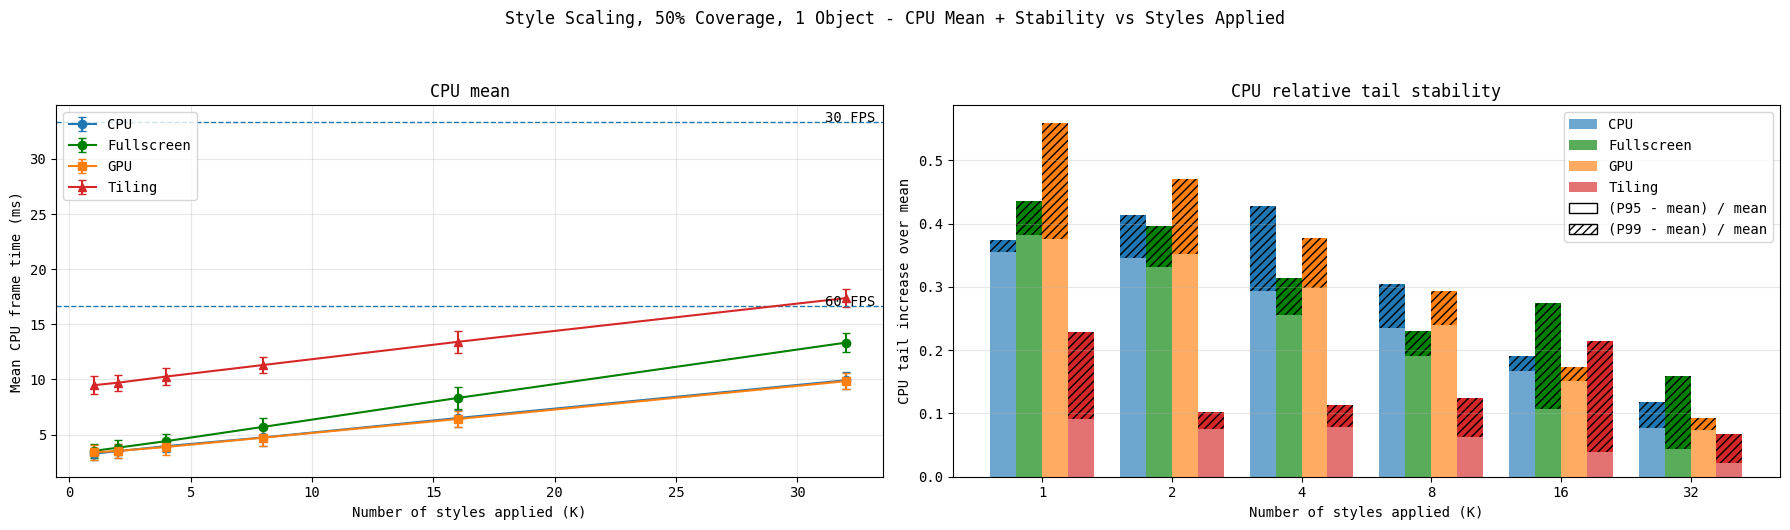

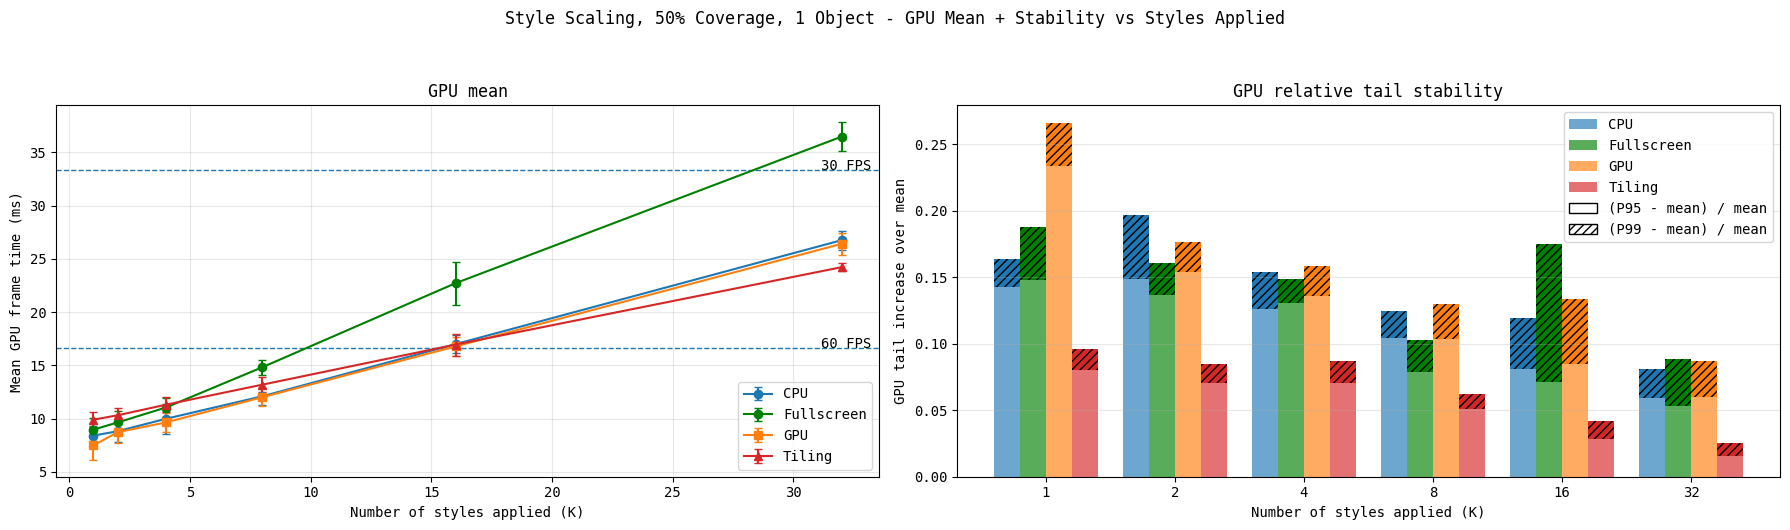

In [1785]:
style_gradient_tables = {}
# for cov in [0, 25, 50, 75, 100]:
for cov in [50]:
    styles_df = select_runs(
        method_df,
        method_family="StyleScaling",
        coverage_variant=f"Cov{cov}",
    )

    plot_metric_and_stability(
        styles_df,
        plot_kind="method",
        metric="cpu",
        title=f"Style Scaling, {cov}% Coverage, 1 Object - CPU Mean + Stability vs Styles Applied",
        x_label="Number of styles applied (K)",
    )

    plot_metric_and_stability(
        styles_df,
        plot_kind="method",
        metric="gpu",
        title=f"Style Scaling, {cov}% Coverage, 1 Object - GPU Mean + Stability vs Styles Applied",
        x_label="Number of styles applied (K)",
    )

    # plot_speedup_lines_all(
    #     styles_df,
    #     plot_kind="method",
    #     title=f"Style Scaling, {cov}% Coverage, 1 Object - Speedup vs K",
    #     x_label="Number of styles applied (K)",
    # )


## Count Scaling

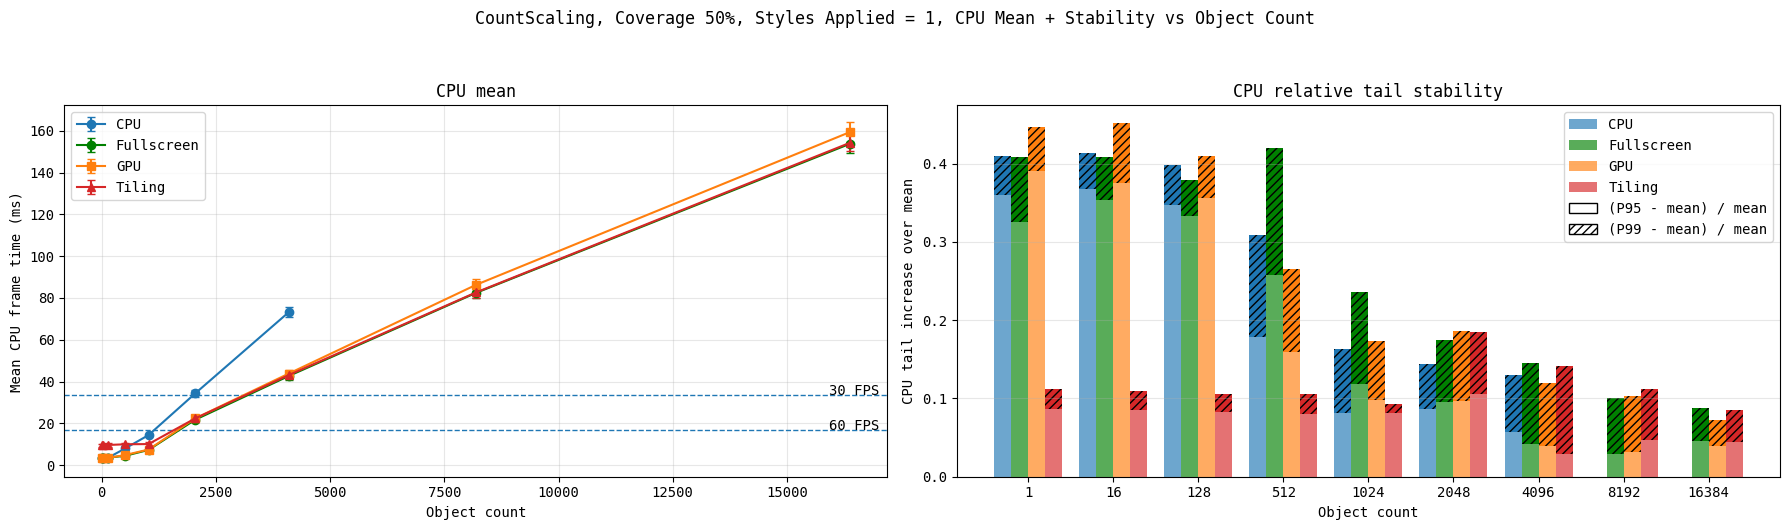

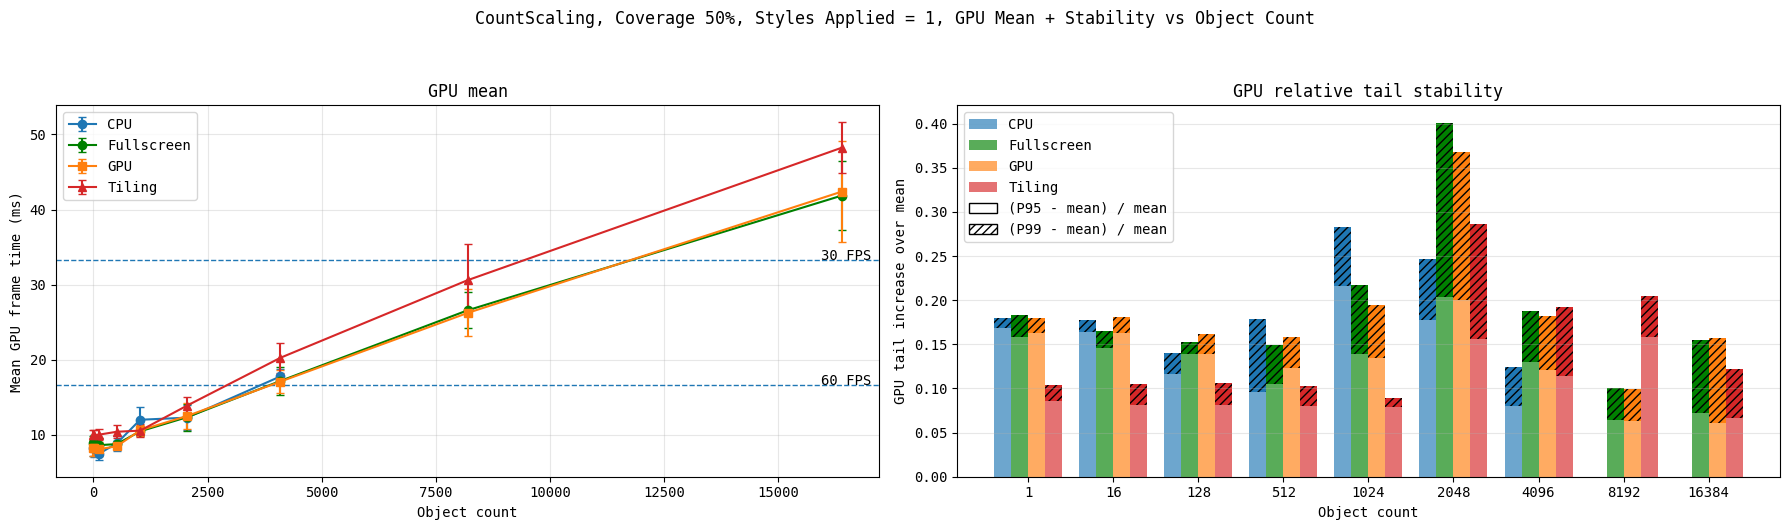

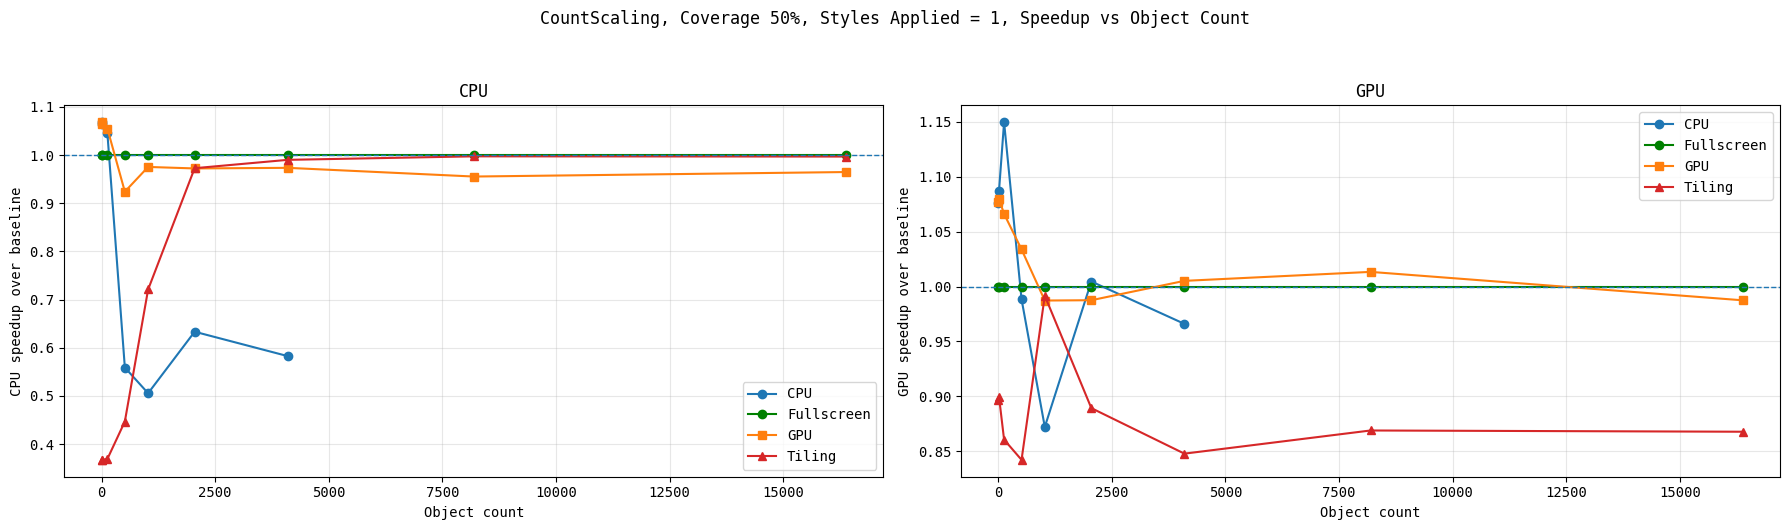

In [1786]:
count_gradient_table = {}
count_cov = select_runs(
    method_df,
    method_family="CountScaling",
    coverage_variant="Cov50",
)

# CPU + stability
plot_metric_and_stability(
    count_cov,
    plot_kind="method",
    metric="cpu",
    K_filter=1,
    x_label="Object count",
    title="CountScaling, Coverage 50%, Styles Applied = 1, CPU Mean + Stability vs Object Count",
)

# GPU + stability
plot_metric_and_stability(
    count_cov,
    plot_kind="method",
    metric="gpu",
    K_filter=1,
    x_label="Object count",
    title="CountScaling, Coverage 50%, Styles Applied = 1, GPU Mean + Stability vs Object Count",
)

# Speedup
plot_speedup_lines_all(
    count_cov,
    plot_kind="method",
    K_filter=1,
    x_label="Object count",
    title="CountScaling, Coverage 50%, Styles Applied = 1, Speedup vs Object Count",
)

# Gradients table

## Coverage Scaling

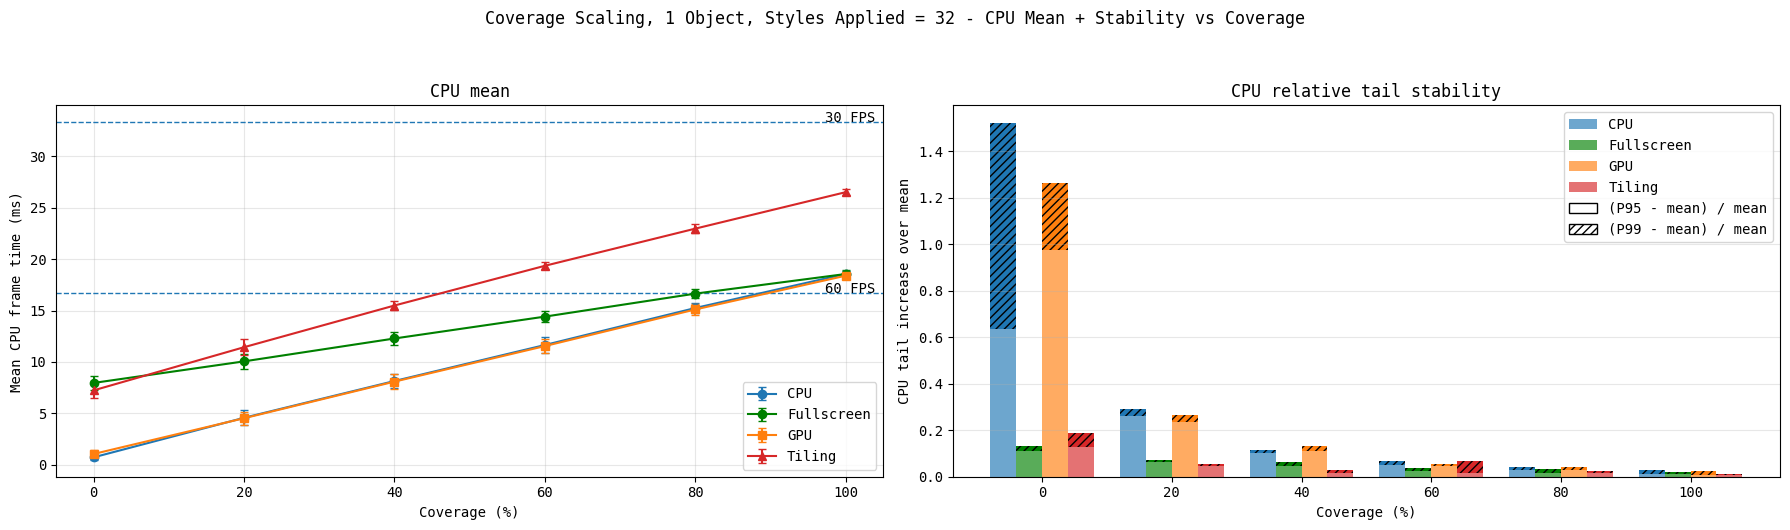

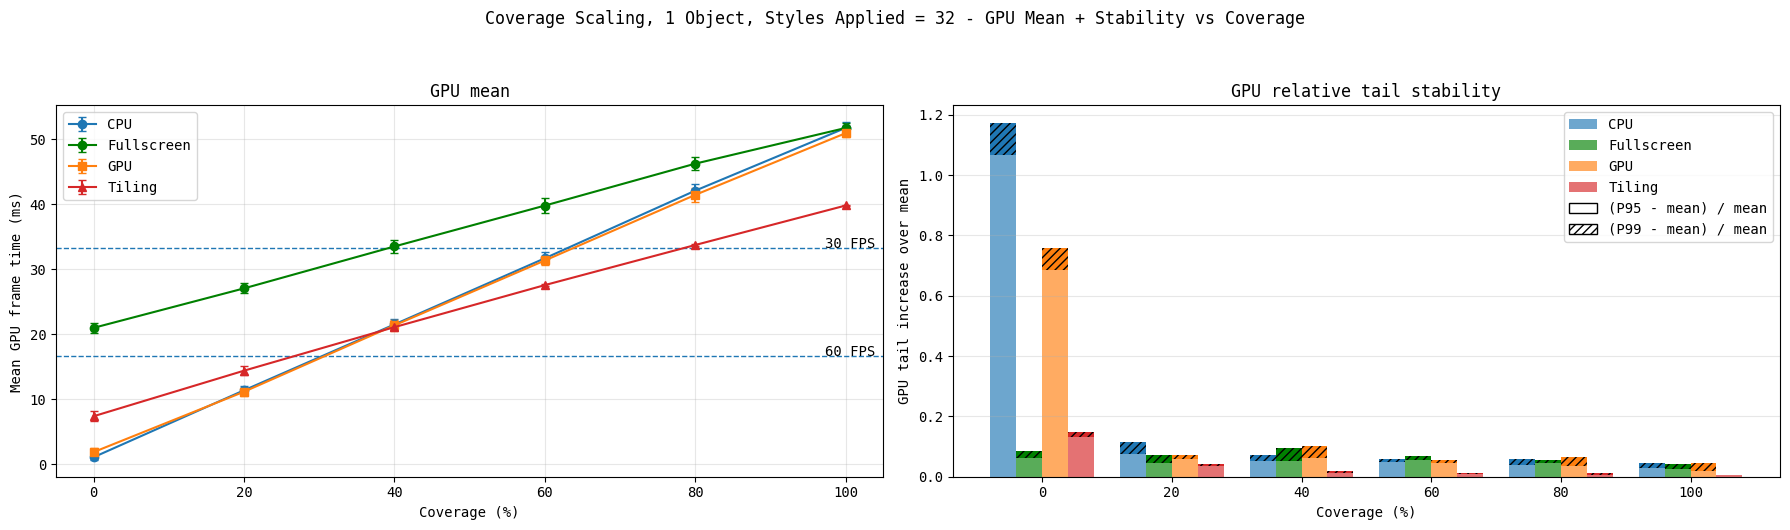

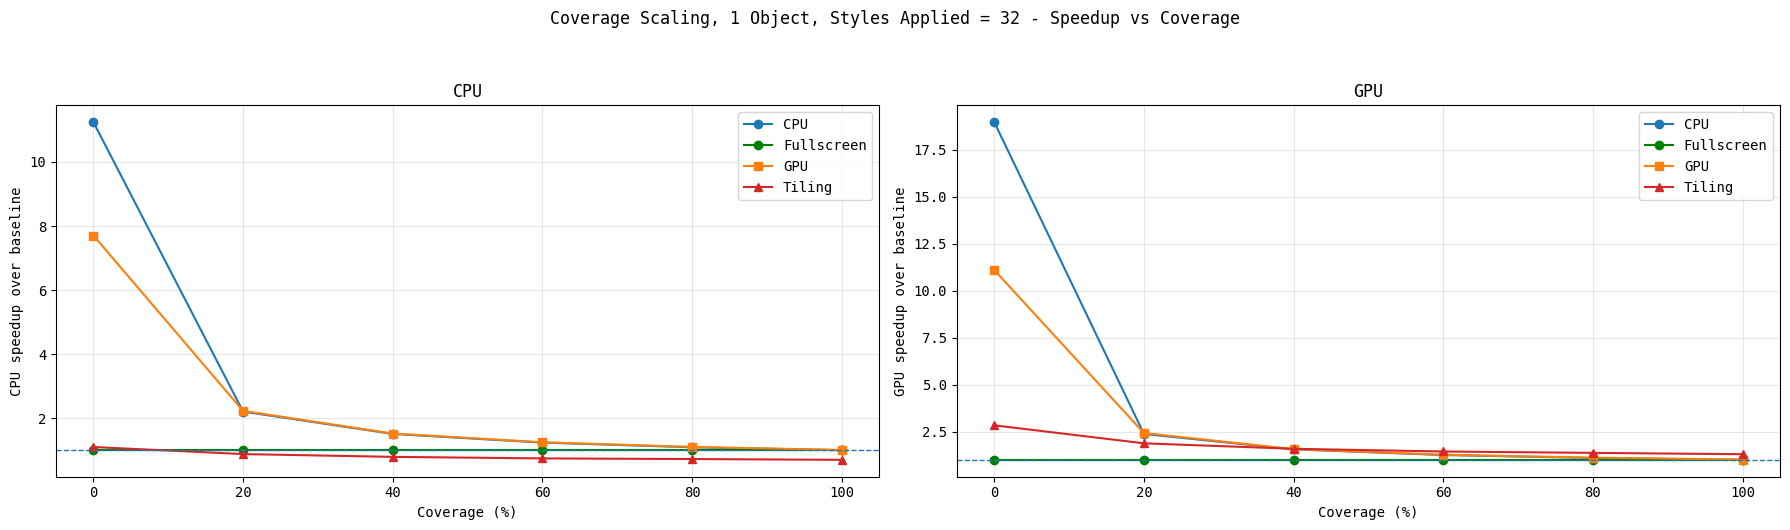

In [1787]:
coverage_gradient_tables = {}
for obj in ["Obj1"]:
    coverage_df = select_runs(
        method_df,
        method_family="CoverageScaling",
        object_variant=obj,
    )

    obj_count = obj.replace("Obj", "")

    for k in [32]:
        coverage_k_df = _apply_k_filter(coverage_df, K_filter=k)

        plot_metric_and_stability(
            coverage_k_df,
            plot_kind="method",
            metric="cpu",
            x_label="Coverage (%)",
            title=f"Coverage Scaling, {obj_count} Object, Styles Applied = {k} - CPU Mean + Stability vs Coverage",
        )

        plot_metric_and_stability(
            coverage_k_df,
            plot_kind="method",
            metric="gpu",
            x_label="Coverage (%)",
            title=f"Coverage Scaling, {obj_count} Object, Styles Applied = {k} - GPU Mean + Stability vs Coverage",
        )

        plot_speedup_lines_all(
            coverage_k_df,
            plot_kind="method",
            x_label="Coverage (%)",
            title=f"Coverage Scaling, {obj_count} Object, Styles Applied = {k} - Speedup vs Coverage",
        )

## Overlap Scaling

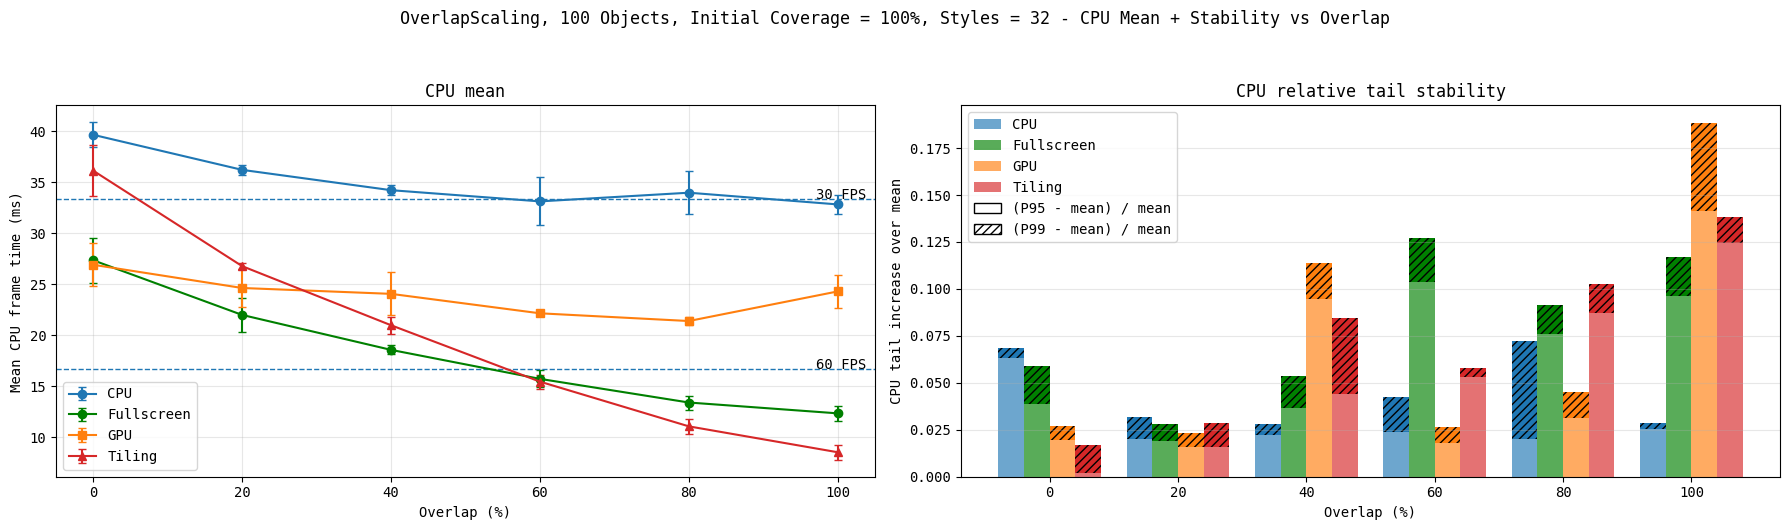

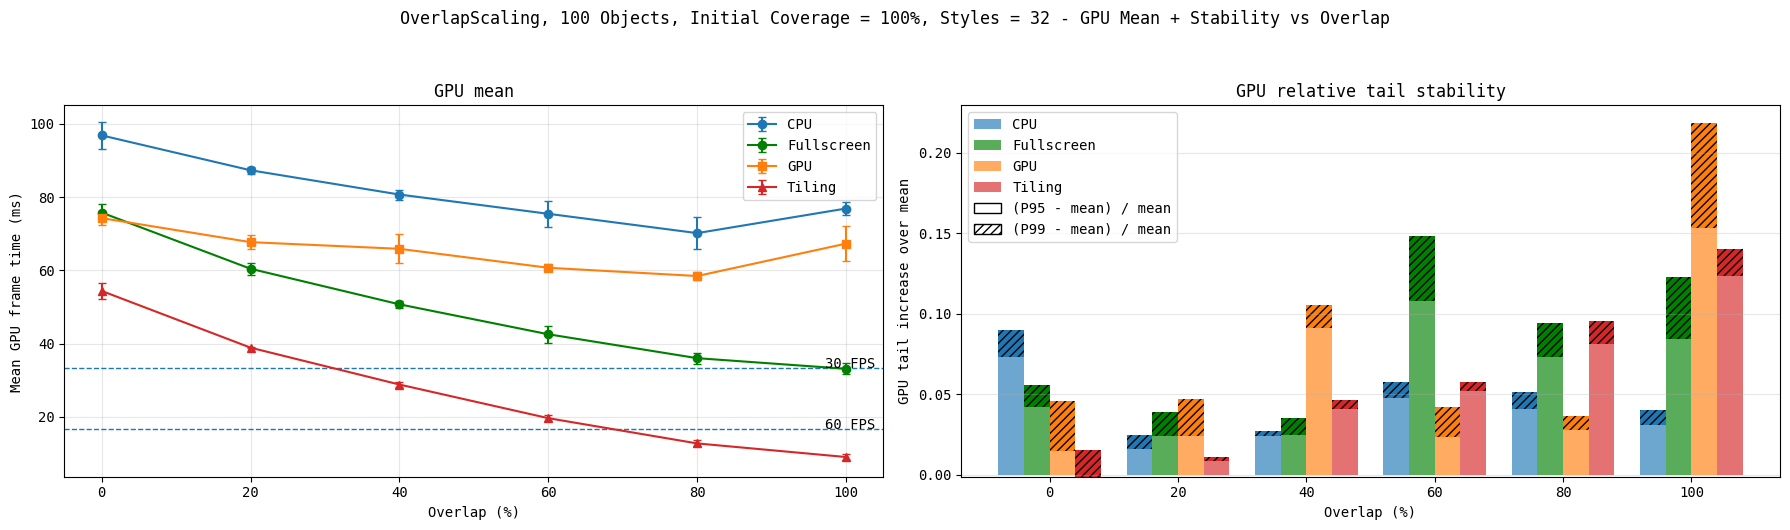

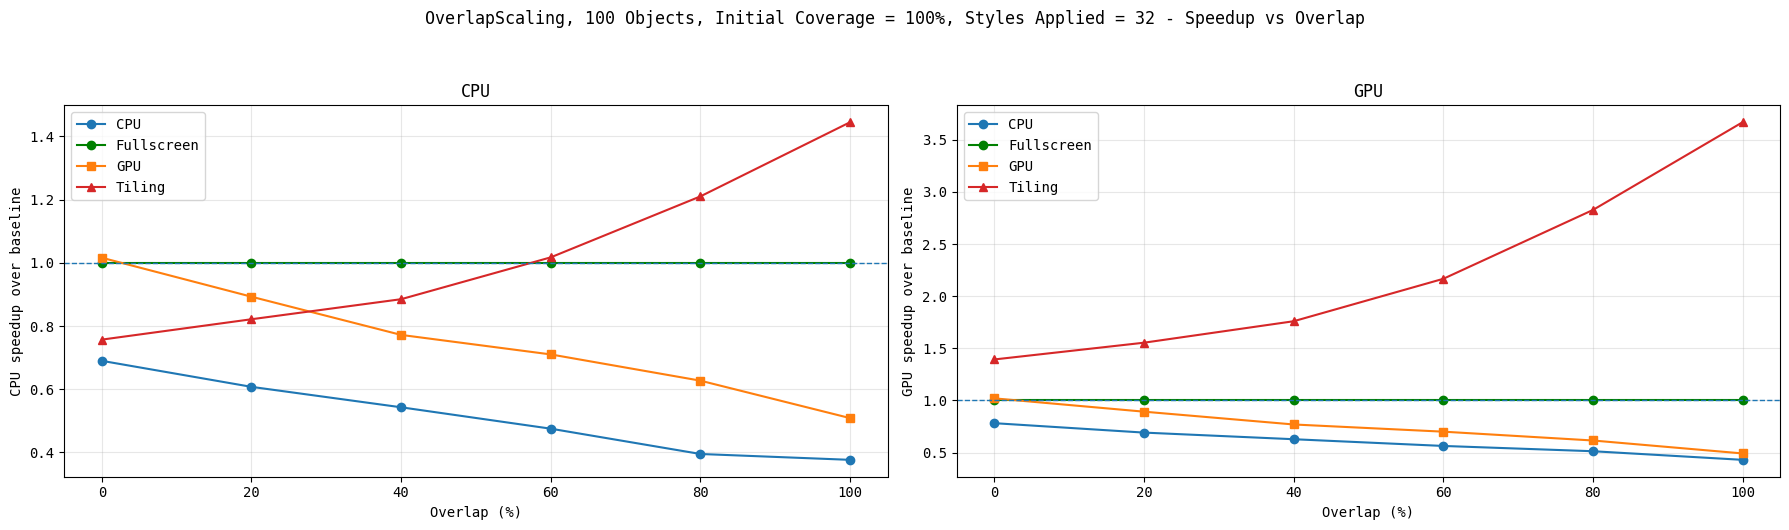

In [1788]:
for obj in ["Obj100"]:
    for shader in ["Default"]:
        overlap_df = select_runs(
            method_df,
            method_family="OverlapScaling",
            object_variant=obj,
            shader_variant=shader,
        )

        obj_count = obj.replace("Obj", "")
        shader_suffix = "" if shader == "Default" else " (Heavy Shader)"

        k_values = [32] if shader == "Default" else [1]

        for k in k_values:
            plot_metric_and_stability(
                overlap_df,
                plot_kind="method",
                metric="cpu",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Initial Coverage = 100%, Styles = {k} - CPU Mean + Stability vs Overlap{shader_suffix}",
            )

            plot_metric_and_stability(
                overlap_df,
                plot_kind="method",
                metric="gpu",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Initial Coverage = 100%, Styles = {k} - GPU Mean + Stability vs Overlap{shader_suffix}",
            )

            plot_speedup_lines_all(
                overlap_df,
                plot_kind="method",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Initial Coverage = 100%, Styles Applied = {k} - Speedup vs Overlap{shader_suffix}",
            )

## Merge Ablation

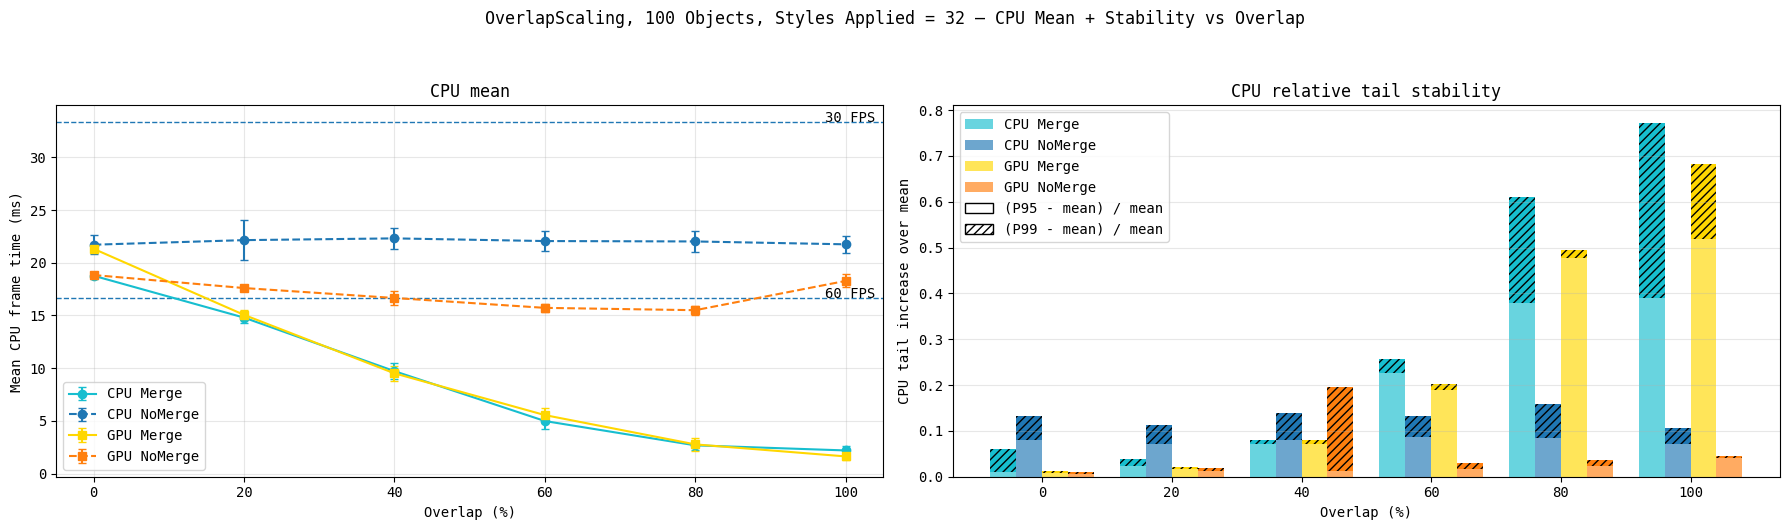

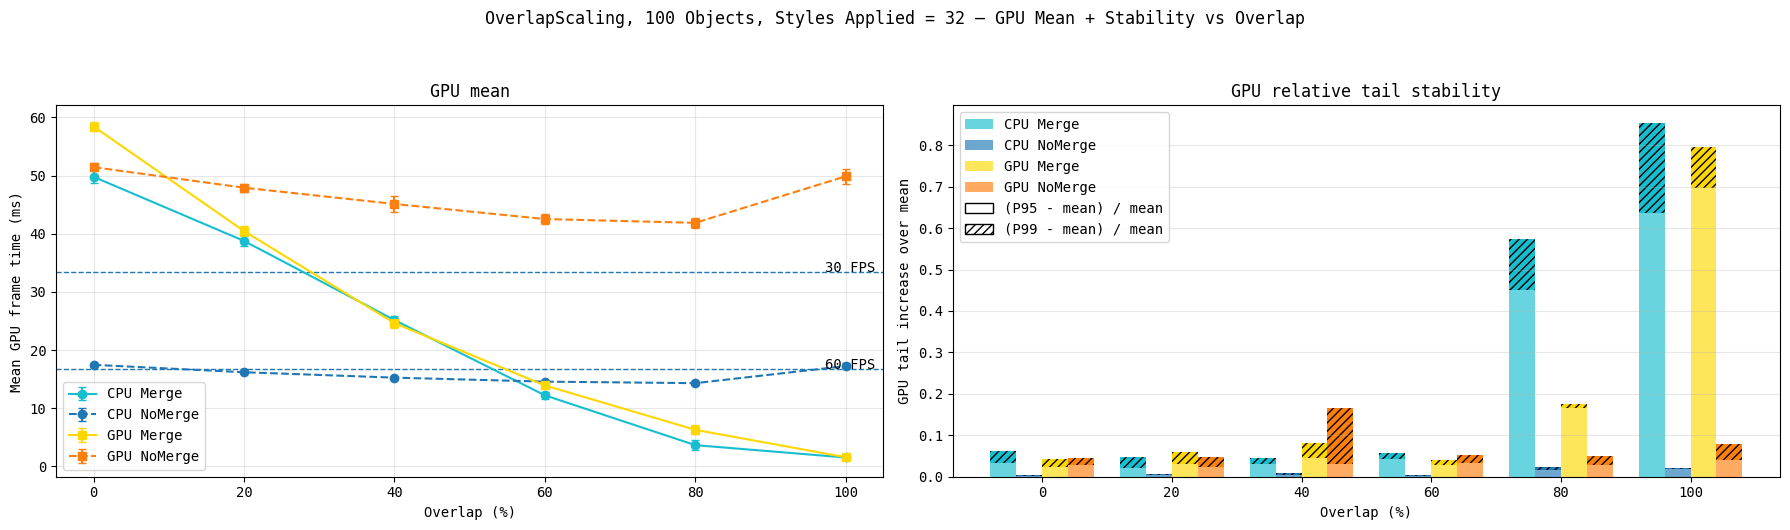

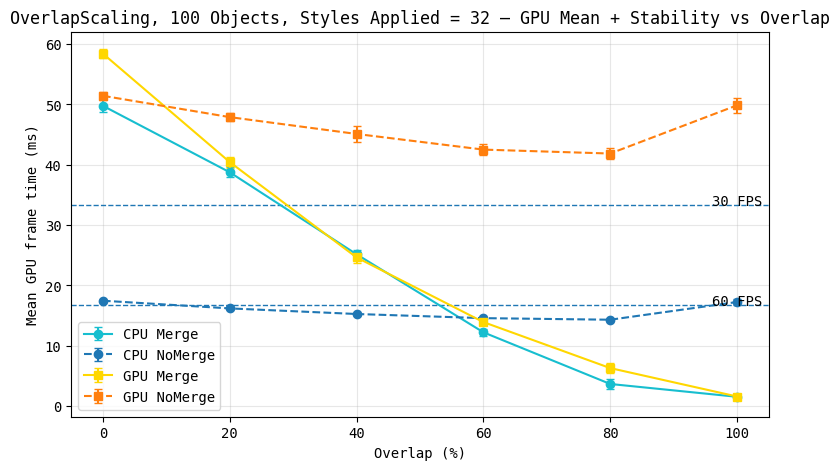

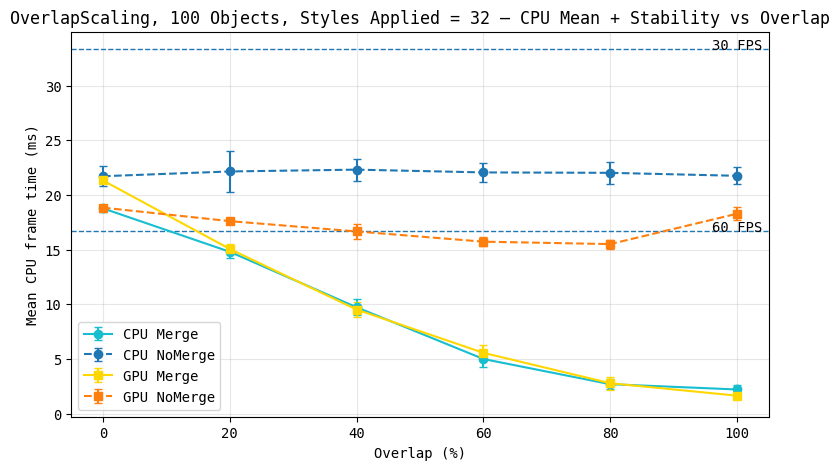

In [1789]:
for obj in ["Obj100"]:
    for shader in ["Default"]:
        count_merge_df = select_runs(
            merge_ablation_df,
            method_family="OverlapScaling",
            object_variant=obj,
            shader_variant=shader,
        )

        obj_count = obj.replace("Obj", "")
        shader_suffix = "" if shader == "Default" else " (Heavy Shader)"

        k_values = [32] if shader == "Default" else [1]

        for k in k_values:
            plot_metric_and_stability(
                count_merge_df,
                plot_kind="merge",
                metric="cpu",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Styles Applied = {k} — CPU Mean + Stability vs Overlap{shader_suffix}",
            )

            plot_metric_and_stability(
                count_merge_df,
                plot_kind="merge",
                metric="gpu",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Styles Applied = {k} — GPU Mean + Stability vs Overlap{shader_suffix}",
            )

            plot_metric_line(
                count_merge_df,
                plot_kind="merge",
                metric="gpu",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Styles Applied = {k} — GPU Mean + Stability vs Overlap{shader_suffix}",
            )
            plot_metric_line(
                count_merge_df,
                plot_kind="merge",
                metric="cpu",
                K_filter=k,
                x_label="Overlap (%)",
                title=f"OverlapScaling, {obj_count} Objects, Styles Applied = {k} — CPU Mean + Stability vs Overlap{shader_suffix}",
            )

## Merging Count Scaling

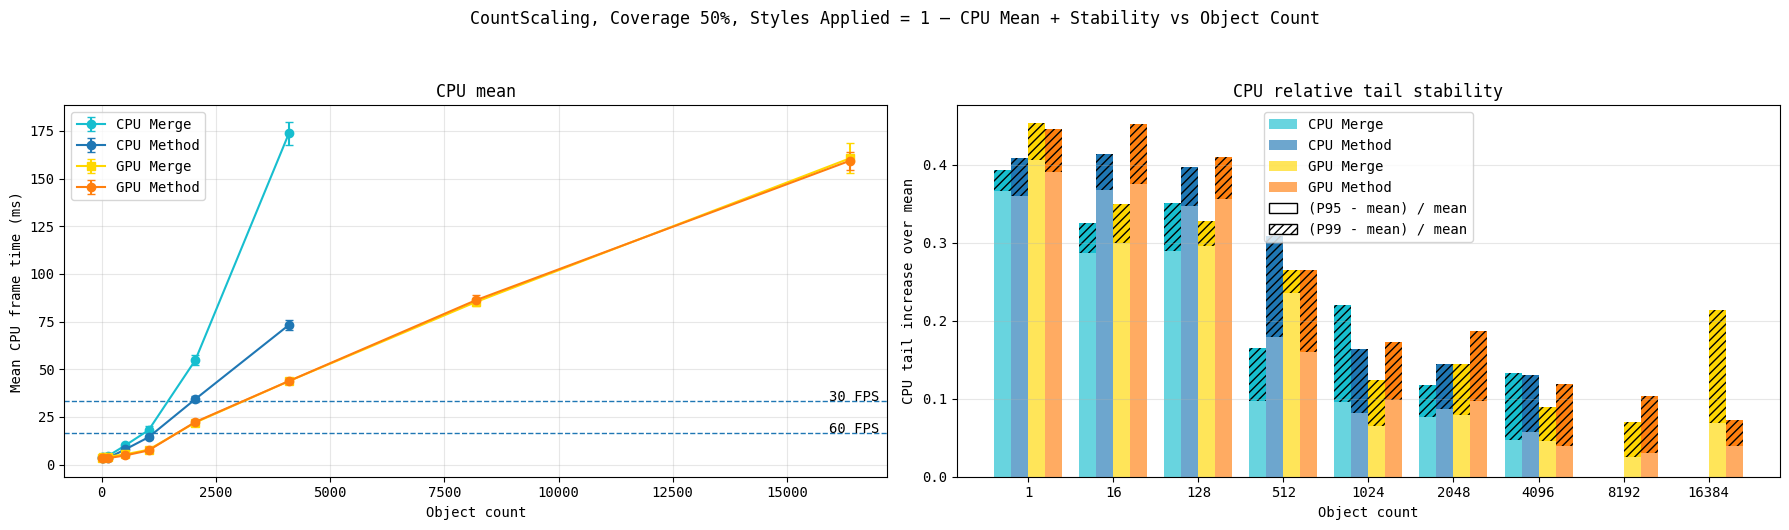

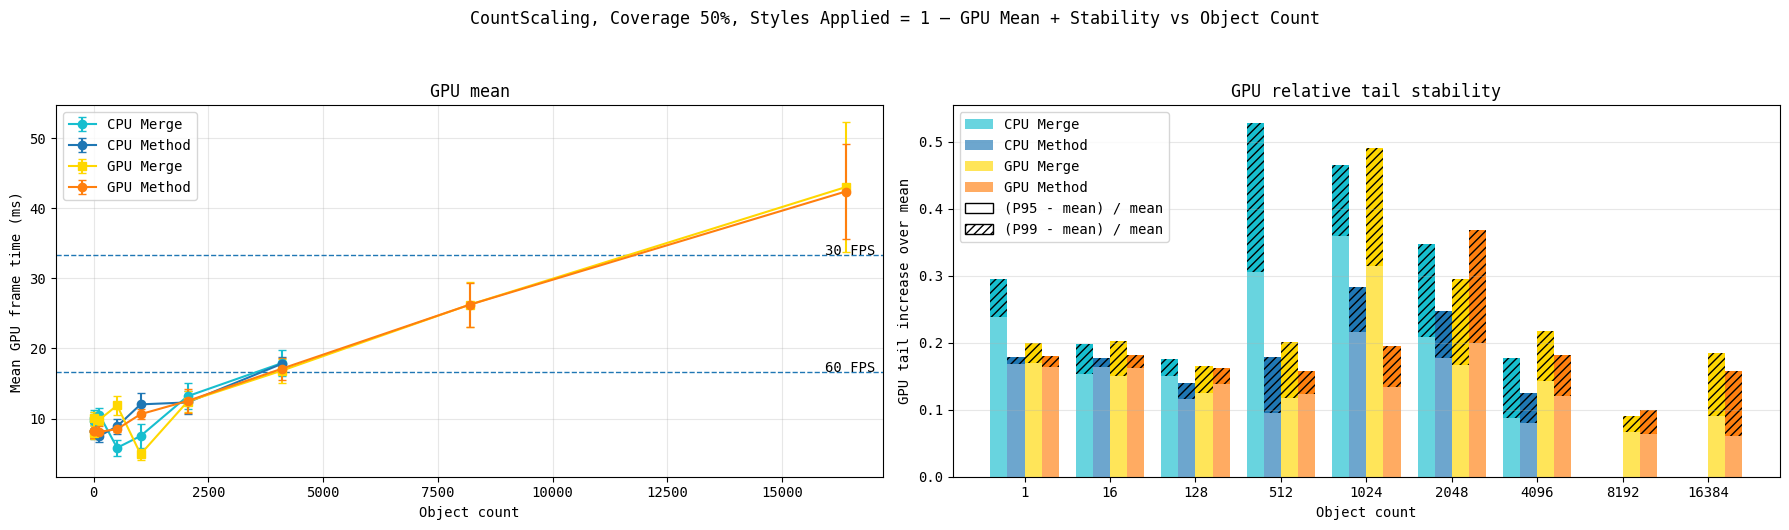

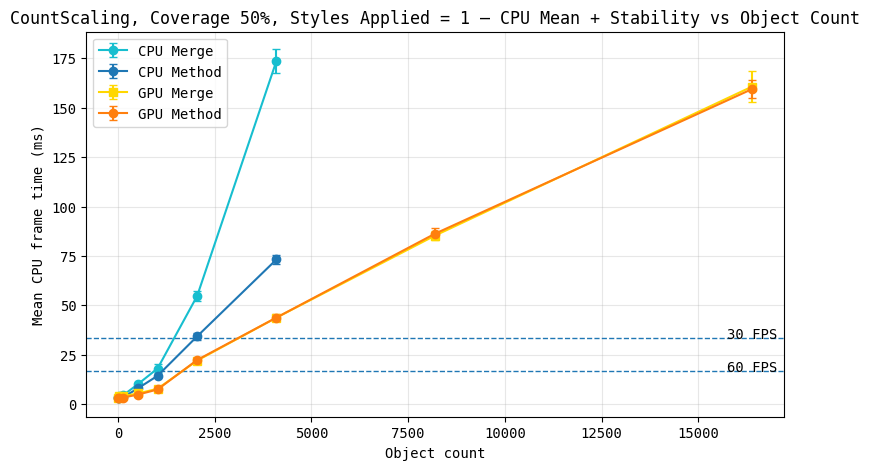

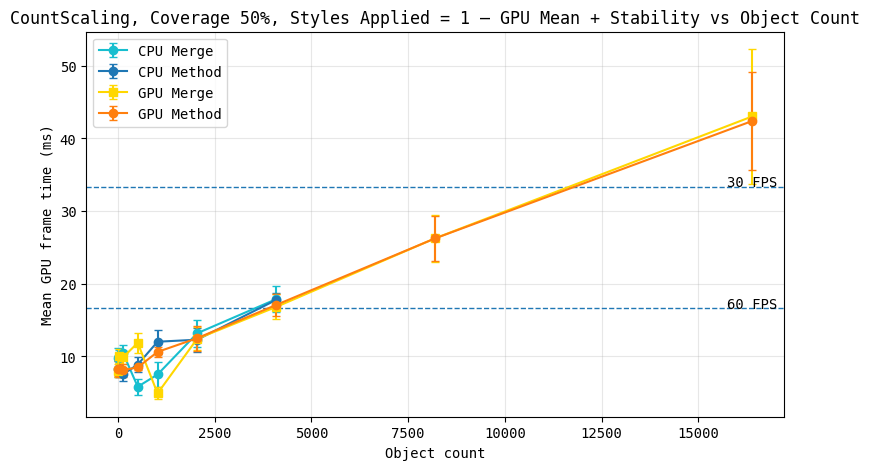

In [1790]:
method_count_df = select_runs(
    method_df,
    method_family="CountScaling",
    coverage_variant="Cov50",
    shader_variant="Default",
    render_mode=["CPU", "GPU"],
).copy()

method_count_df["merge_ablation"] = "Method"

count_merge_df = select_runs(
    merge_ablation_df,
    method_family="CountScaling",
    coverage_variant="Cov50",
    shader_variant="Default",
    render_mode=["CPU", "GPU"],
).copy()

combined_count_merge_df = pd.concat(
    [method_count_df, count_merge_df],
    ignore_index=True,
)

for k in [1]:
    if combined_count_merge_df[combined_count_merge_df["k"] == k].empty:
        continue

    plot_metric_and_stability(
        combined_count_merge_df,
        plot_kind="merge",
        metric="cpu",
        K_filter=k,
        x_label="Object count",
        title=f"CountScaling, Coverage 50%, Styles Applied = {k} — CPU Mean + Stability vs Object Count",
    )

    plot_metric_and_stability(
        combined_count_merge_df,
        plot_kind="merge",
        metric="gpu",
        K_filter=k,
        x_label="Object count",
        title=f"CountScaling, Coverage 50%, Styles Applied = {k} — GPU Mean + Stability vs Object Count",
    )

    plot_metric_line(
        combined_count_merge_df,
        plot_kind="merge",
        metric="cpu",
        K_filter=k,
        x_label="Object count",
        title=f"CountScaling, Coverage 50%, Styles Applied = {k} — CPU Mean + Stability vs Object Count",
    )

    plot_metric_line(
        combined_count_merge_df,
        plot_kind="merge",
        metric="gpu",
        K_filter=k,
        x_label="Object count",
        title=f"CountScaling, Coverage 50%, Styles Applied = {k} — GPU Mean + Stability vs Object Count",
    )

## Occlusion Scaling

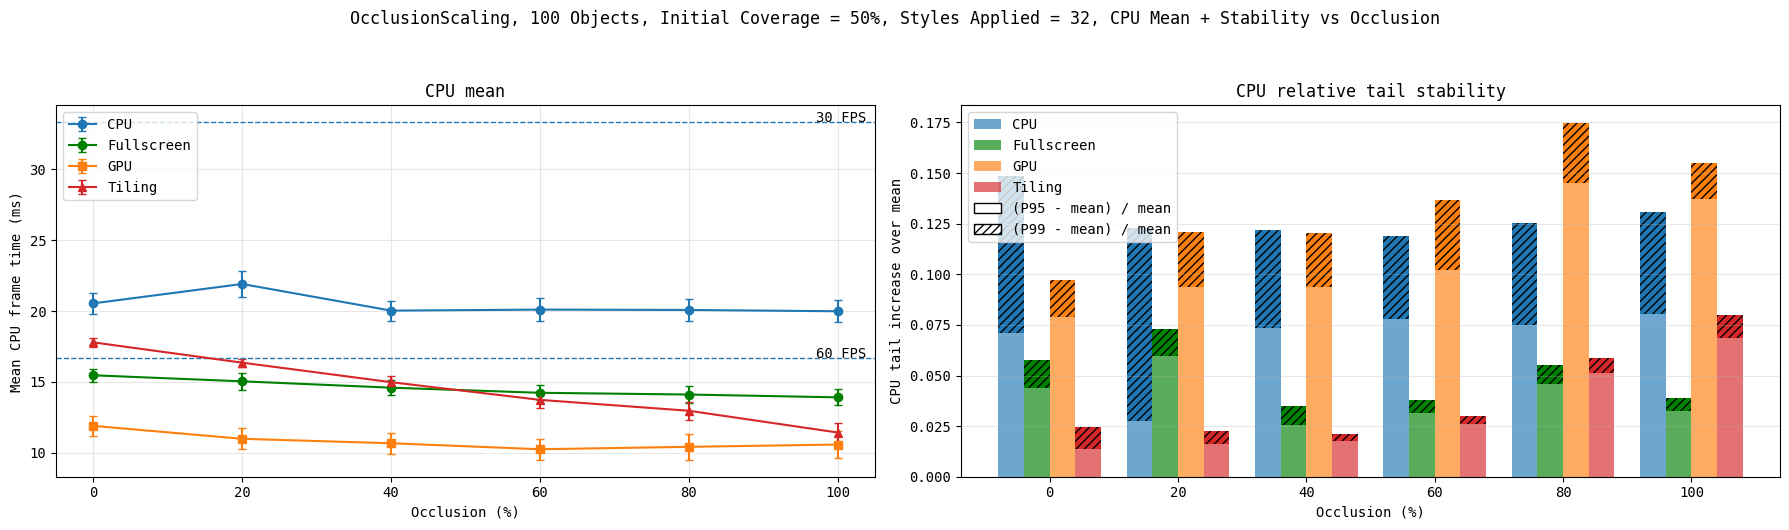

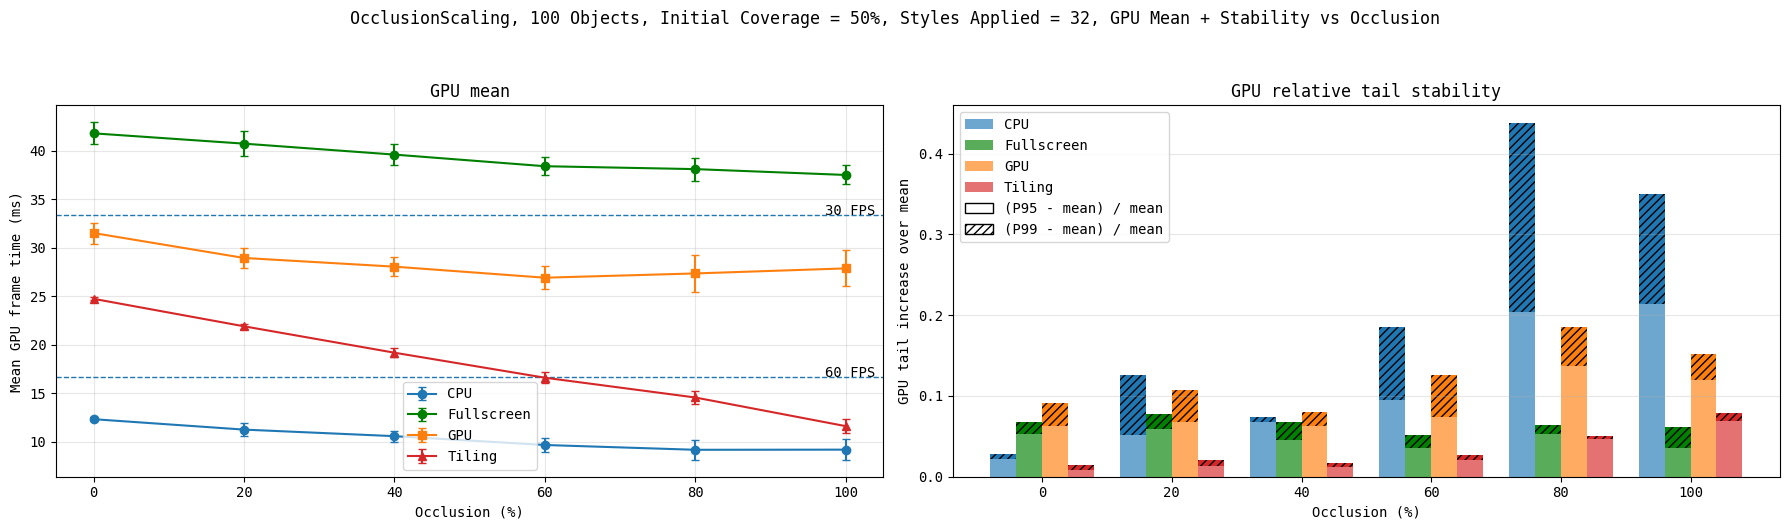

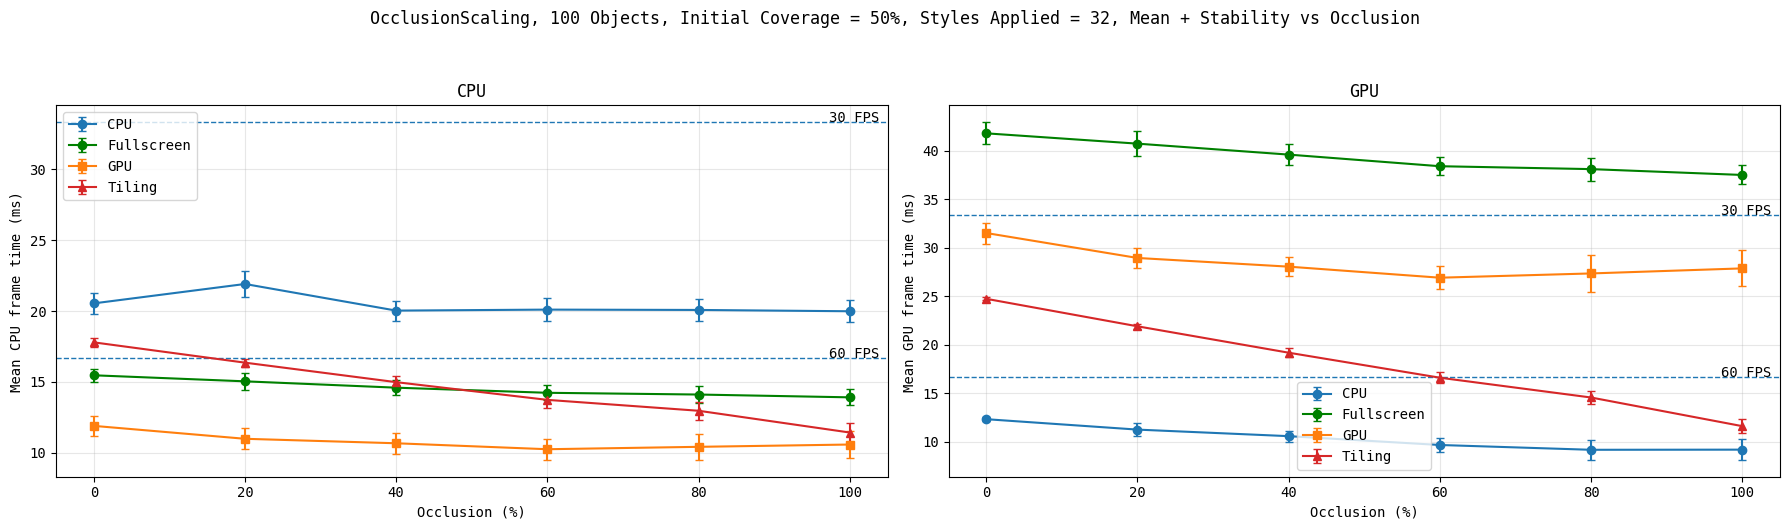

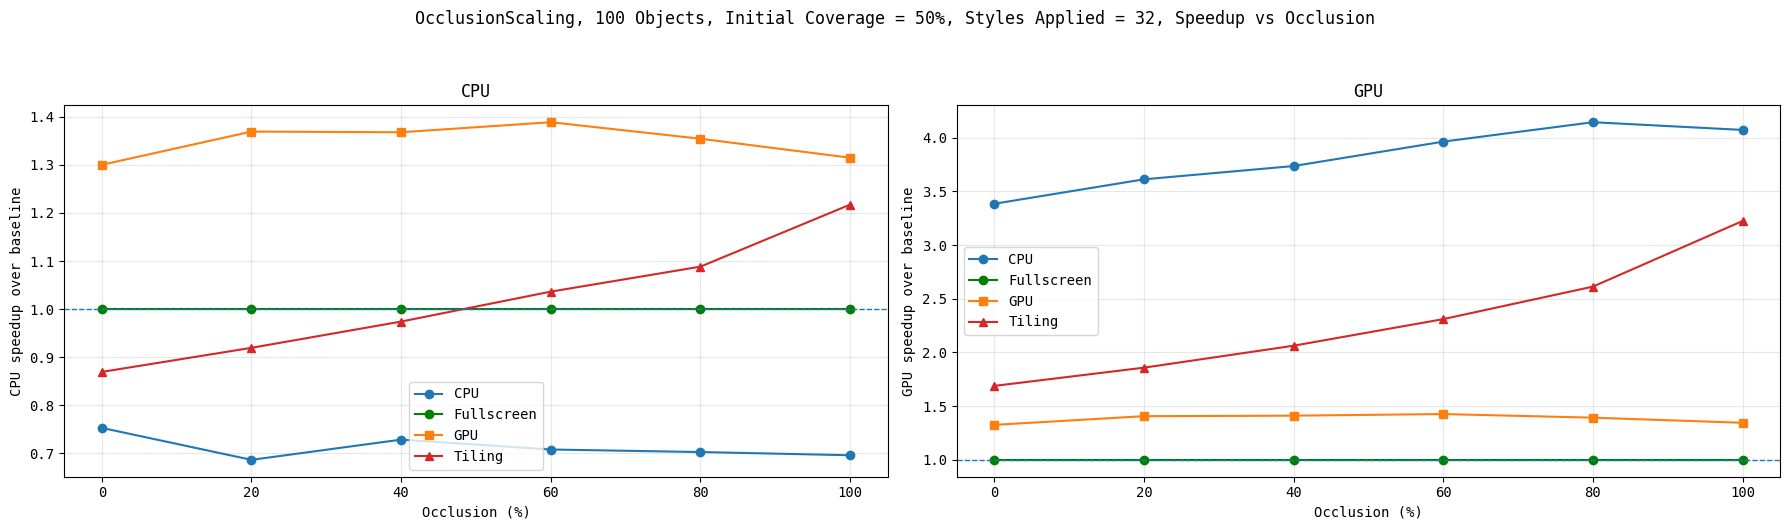

In [1791]:
# Occlusion scaling tests
for obj in [100]:
    occlusion_obj = select_runs(
        method_df,
        method_family="OcclusionScaling",
        object_variant=f"Obj{obj}",
        shader_variant="Default",
    )

    for k in [32]:
        if occlusion_obj[occlusion_obj["k"] == k].empty:
            continue

        plot_metric_and_stability(
            occlusion_obj,
            plot_kind="method",
            metric="cpu",
            K_filter=k,
            x_label="Occlusion (%)",
            title=f"OcclusionScaling, {obj} Objects, Initial Coverage = 50%, Styles Applied = {k}, CPU Mean + Stability vs Occlusion",
        )

        plot_metric_and_stability(
            occlusion_obj,
            plot_kind="method",
            metric="gpu",
            K_filter=k,
            x_label="Occlusion (%)",
            title=f"OcclusionScaling, {obj} Objects, Initial Coverage = 50%, Styles Applied = {k}, GPU Mean + Stability vs Occlusion",
        )

        plot_metric_lines_all3(
            occlusion_obj,
            plot_kind="method",
            K_filter=k,
            x_label="Occlusion (%)",
            title=f"OcclusionScaling, {obj} Objects, Initial Coverage = 50%, Styles Applied = {k}, Mean + Stability vs Occlusion",      
        )

        plot_speedup_lines_all(
            occlusion_obj,
            plot_kind="method",
            K_filter=k,
            x_label="Occlusion (%)",
            title=f"OcclusionScaling, {obj} Objects, Initial Coverage = 50%, Styles Applied = {k}, Speedup vs Occlusion",
        )

## Occlusion Ablation

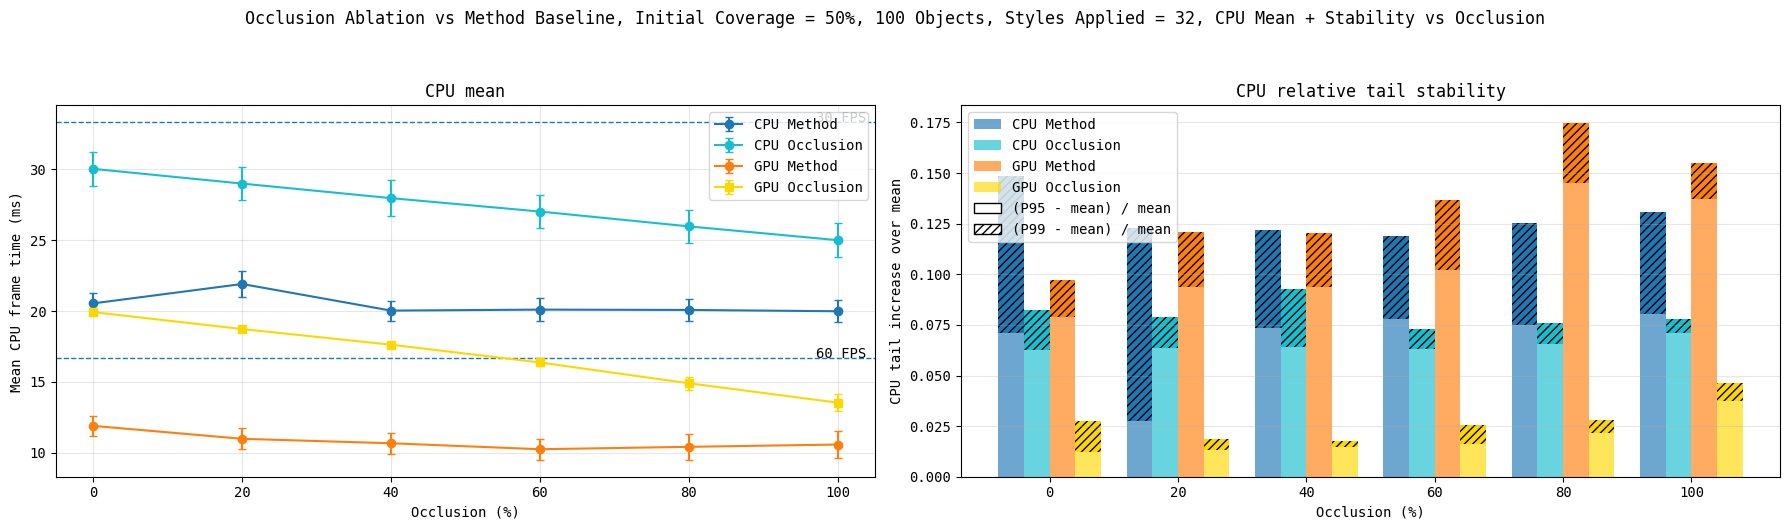

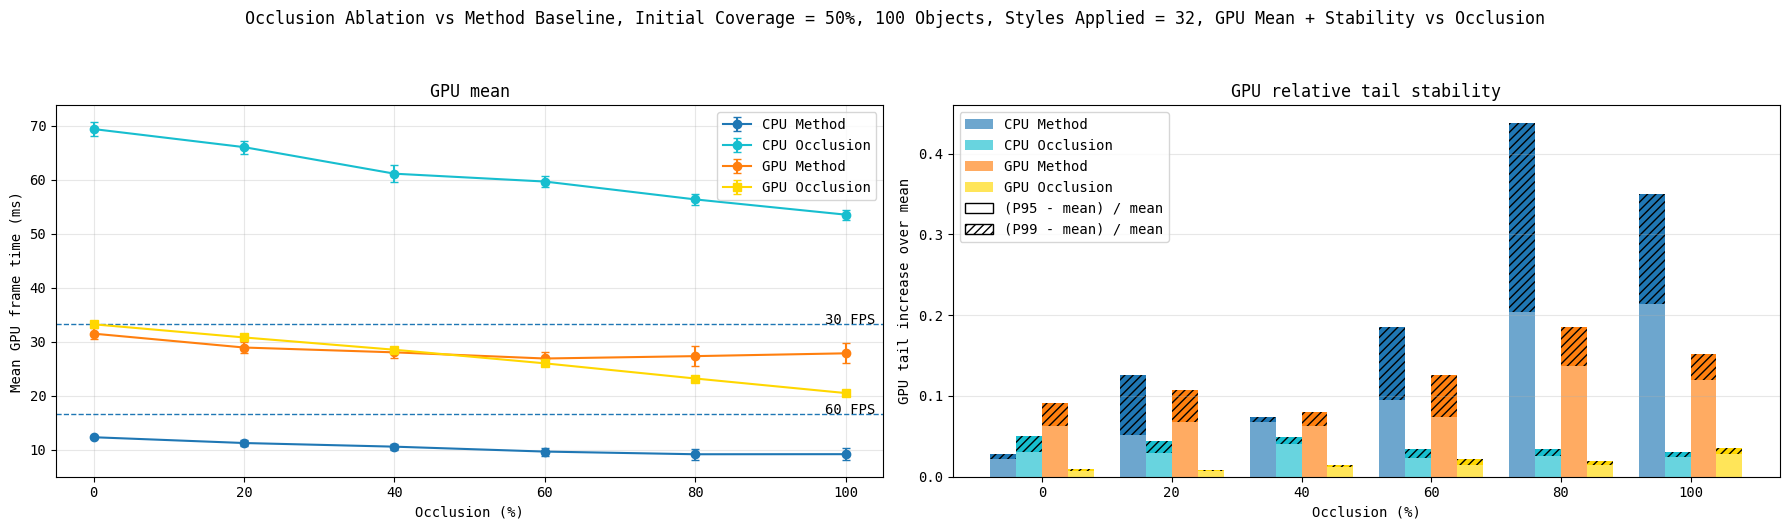

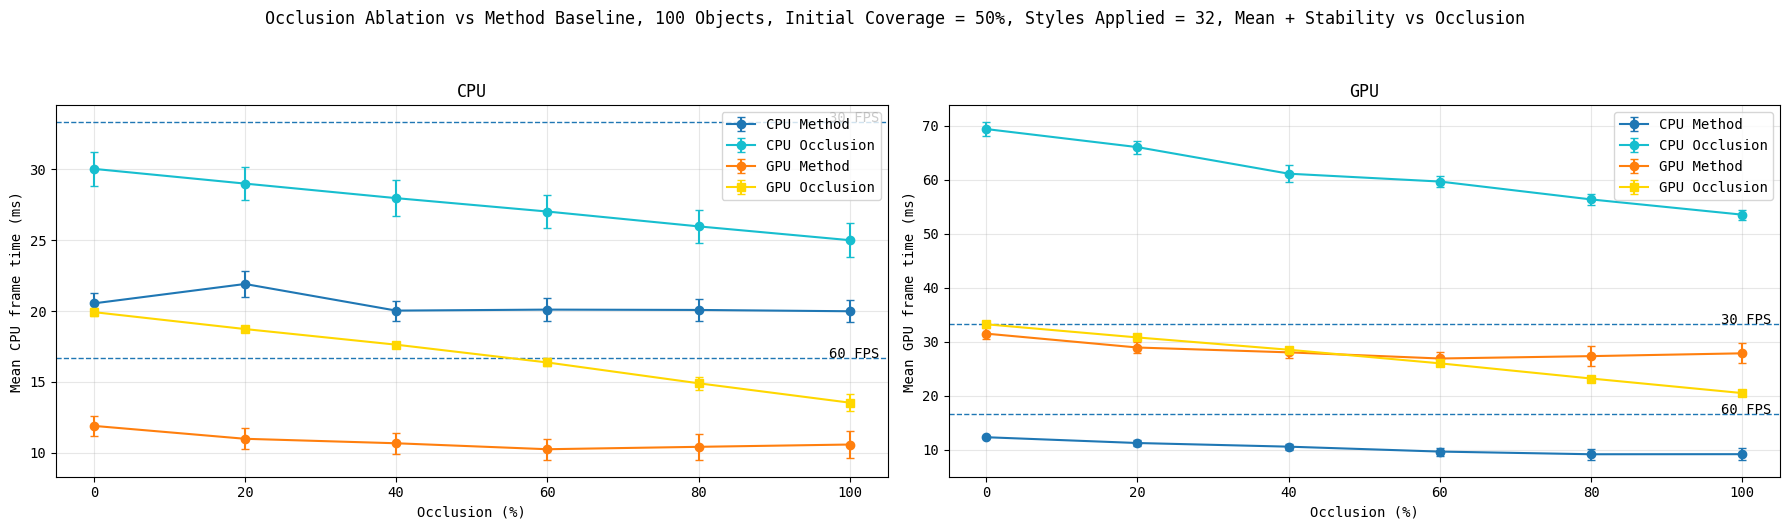

In [1792]:
method_occlusion_obj100 = select_runs(
    method_df,
    method_family="OcclusionScaling",
    object_variant="Obj100",
    coverage_variant="Cov50",
    shader_variant="Default",
    render_mode=["CPU", "GPU"],
).copy()

method_occlusion_obj100["occlusion_ablation"] = "Method"

occlusion_ablation_obj100 = select_runs(
    occlusion_ablation_df,
    method_family="OcclusionScaling",
    object_variant="Obj100",
    shader_variant="Default",
    render_mode=["CPU", "GPU"],
).copy()

combined_occlusion_obj100 = pd.concat(
    [method_occlusion_obj100, occlusion_ablation_obj100],
    ignore_index=True,
)

for k in [32]:
    if combined_occlusion_obj100[combined_occlusion_obj100["k"] == k].empty:
        continue

    plot_metric_and_stability(
        combined_occlusion_obj100,
        plot_kind="occlusion",
        metric="cpu",
        K_filter=k,
        x_label="Occlusion (%)",
        title=f"Occlusion Ablation vs Method Baseline, Initial Coverage = 50%, 100 Objects, Styles Applied = {k}, CPU Mean + Stability vs Occlusion",
    )

    plot_metric_and_stability(
        combined_occlusion_obj100,
        plot_kind="occlusion",
        metric="gpu",
        K_filter=k,
        x_label="Occlusion (%)",
        title=f"Occlusion Ablation vs Method Baseline, Initial Coverage = 50%, 100 Objects, Styles Applied = {k}, GPU Mean + Stability vs Occlusion",
    )

    plot_metric_lines_all3(
        combined_occlusion_obj100,
        plot_kind="occlusion",
        K_filter=k,
        x_label="Occlusion (%)",
        title=f"Occlusion Ablation vs Method Baseline, 100 Objects, Initial Coverage = 50%, Styles Applied = {k}, Mean + Stability vs Occlusion",      
    )


## Tiling Ablation

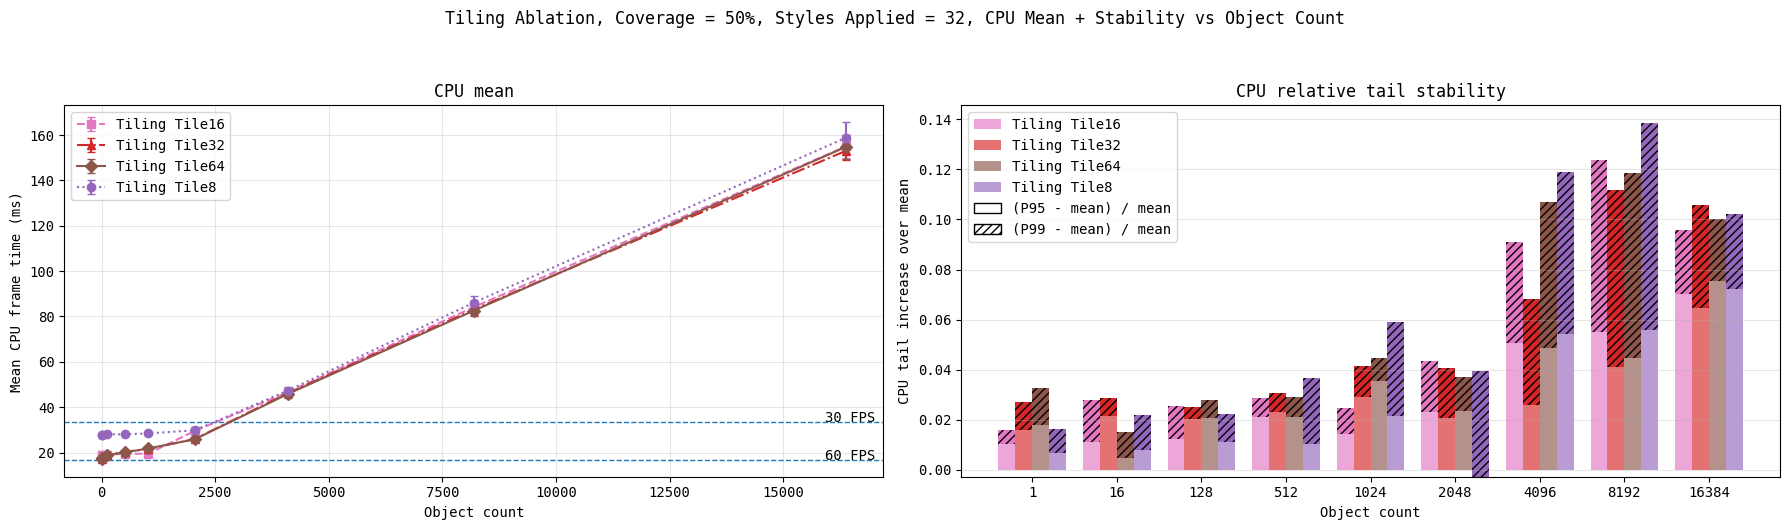

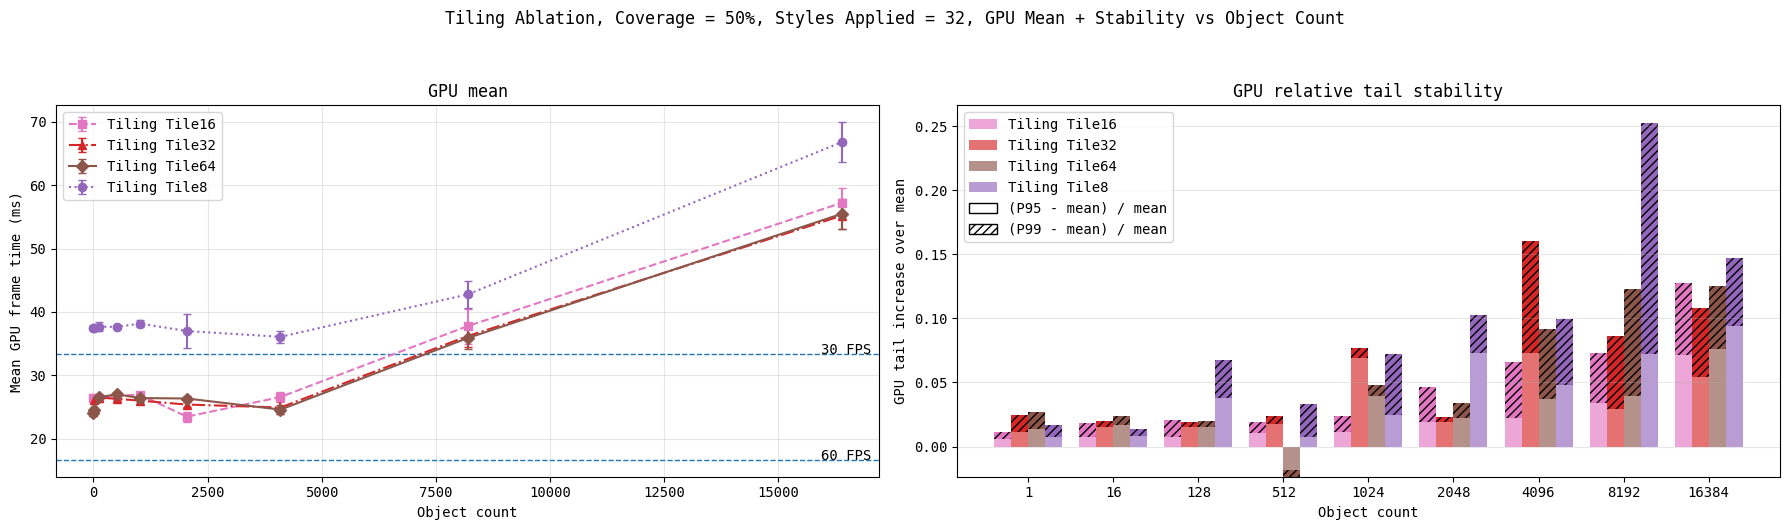

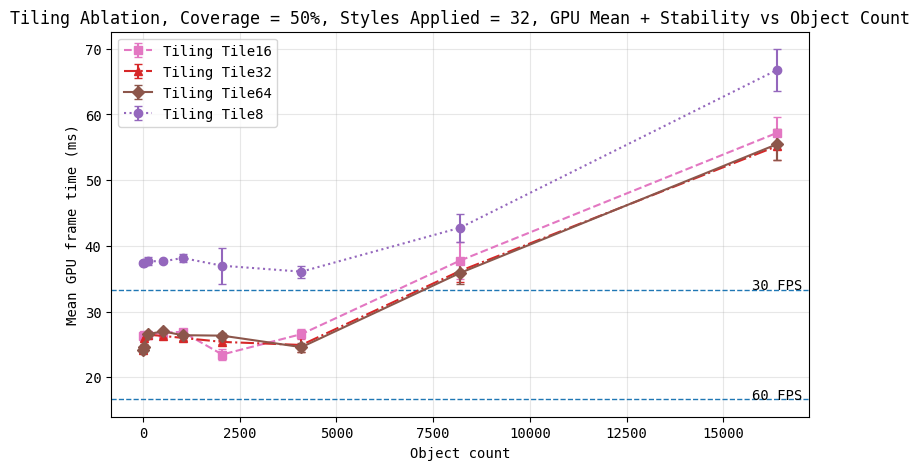

In [1793]:
tiling_cov50 = select_runs(
    tiling_ablation_df,
    method_family="CountScaling",
    coverage_variant="Cov50",
)

for k in [32]:
    plot_metric_and_stability(
        tiling_cov50,
        plot_kind="tiling_ablation",
        metric="cpu",
        K_filter=k,
        x_label="Object count",
        title=f"Tiling Ablation, Coverage = 50%, Styles Applied = {k}, CPU Mean + Stability vs Object Count",
    )

    plot_metric_and_stability(
        tiling_cov50,
        plot_kind="tiling_ablation",
        metric="gpu",
        K_filter=k,
        x_label="Object count",
        title=f"Tiling Ablation, Coverage = 50%, Styles Applied = {k}, GPU Mean + Stability vs Object Count",
    )

    plot_metric_line(
        tiling_cov50,
        plot_kind="tiling_ablation",
        metric="gpu",
        K_filter=k,
        x_label="Object count",
        title=f"Tiling Ablation, Coverage = 50%, Styles Applied = {k}, GPU Mean + Stability vs Object Count",
    )

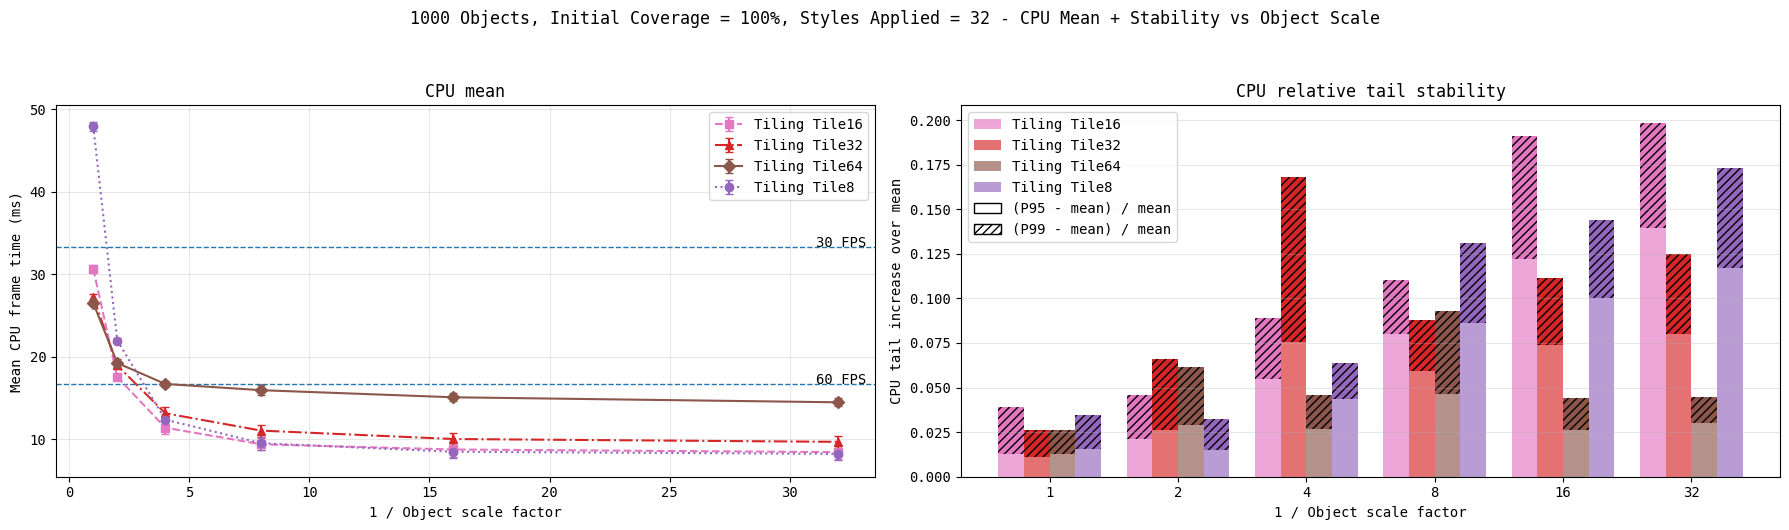

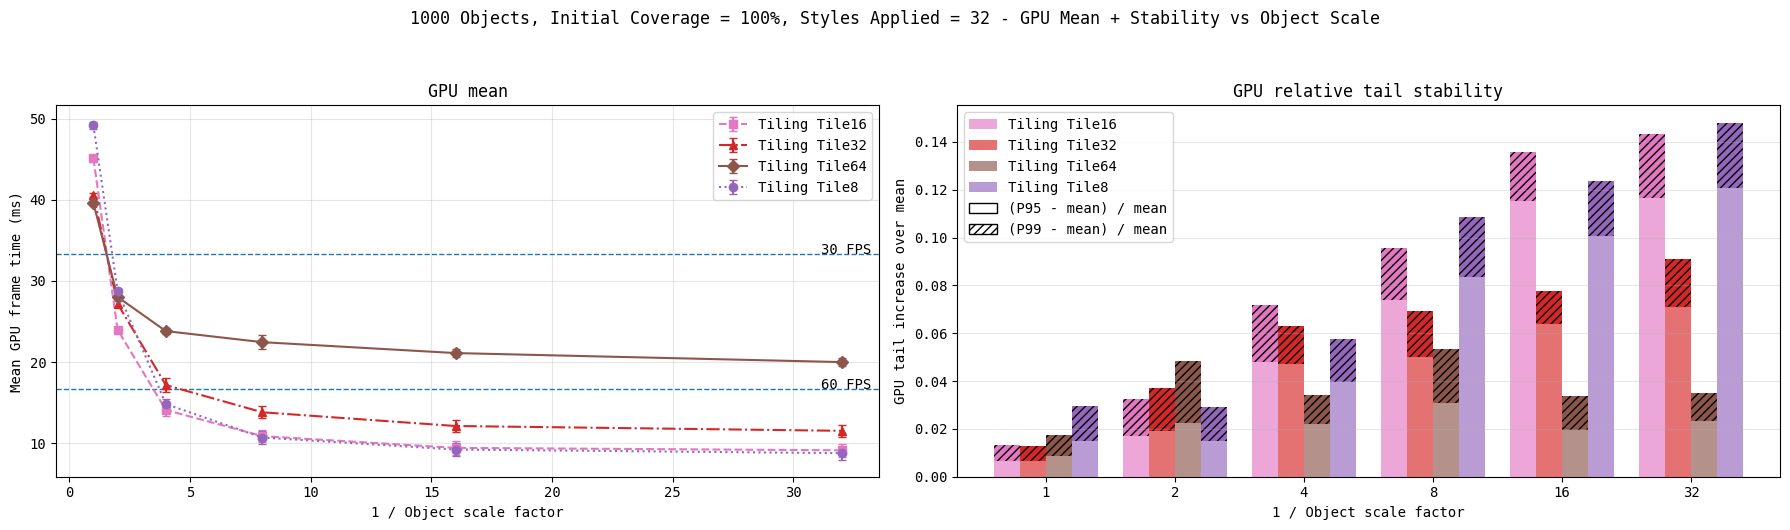

<Axes: title={'center': '1000 Objects, Initial Coverage = 100%, Styles Applied = 32 - GPU Mean + Stability vs Object Scale'}, xlabel='1 / Object scale factor', ylabel='Mean GPU frame time (ms)'>

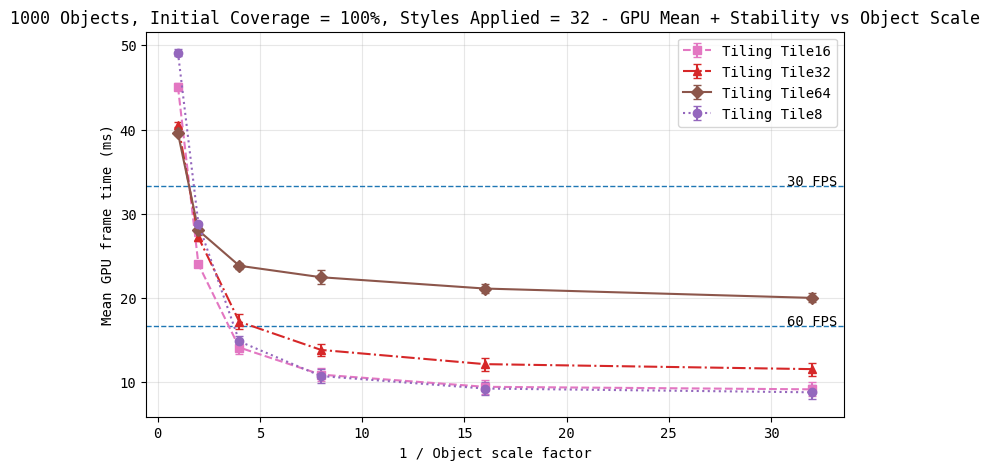

In [1794]:
tiling_object_scale_df = df[
    (df["render_mode"] == "Tiling") &
    (df["method_family"] == "TilingObjectScale") &
    (df["tiling_ablation"].isin(["Tile8", "Tile16", "Tile32", "Tile64"]))
].copy()

tiling_object_scale_df["object_scale_factor"] = tiling_object_scale_df["value"]

tiling_scale_obj1000 = select_runs(
    tiling_object_scale_df,
    object_variant="Obj1000",
)

plot_metric_and_stability(
    tiling_scale_obj1000,
    x_col="object_scale_factor",
    plot_kind="tiling_ablation",
    metric="cpu",
    x_label="1 / Object scale factor",
    title="1000 Objects, Initial Coverage = 100%, Styles Applied = 32 - CPU Mean + Stability vs Object Scale",
)

plot_metric_and_stability(
    tiling_scale_obj1000,
    x_col="object_scale_factor",
    plot_kind="tiling_ablation",
    metric="gpu",
    x_label="1 / Object scale factor",
    title="1000 Objects, Initial Coverage = 100%, Styles Applied = 32 - GPU Mean + Stability vs Object Scale",
)

plot_metric_line(
    tiling_scale_obj1000,
    x_col="object_scale_factor",
    plot_kind="tiling_ablation",
    metric="gpu",
    x_label="1 / Object scale factor",
    title="1000 Objects, Initial Coverage = 100%, Styles Applied = 32 - GPU Mean + Stability vs Object Scale",
)
